# Imports

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import sweetviz as sv
import matplotlib.pyplot as plt
import plotly.express as px
import nbformat
from matplotlib import gridspec
from geopy.geocoders import Nominatim
import sys
import ipywidgets as widgets
import pandas as pd
from matplotlib import gridspec
from matplotlib import pyplot as plt
from ipywidgets import fixed

/home/felipe/anaconda3/envs/pdsdev_env/lib/python3.10/site-packages/sweetviz/graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


# Helper function

In [3]:
#supressão da notação cientifica
pd.set_option('display.float_format',lambda x: '%.2f' %x)

In [4]:
print(sys.version)

3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]


# Loading data

In [5]:
data = pd.read_csv('./datasets/kc_house_data.csv')

# Dataset overview

In [6]:
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.00,3,1.00,1180,5650,1.00,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,538000.00,3,2.25,2570,7242,2.00,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,180000.00,2,1.00,770,10000,1.00,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,604000.00,4,3.00,1960,5000,1.00,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,510000.00,3,2.00,1680,8080,1.00,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [7]:
columns = list(data.columns)
columns

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

In [8]:
# Data dimension
print('Number of rows: {}'.format(data.shape[0]))
print('Number of coluns: {}'.format(data.shape[1]))

Number of rows: 21613
Number of coluns: 21


In [9]:
# Data types
data.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [10]:
# Changing date type
data['date'] = pd.to_datetime(data['date'])

In [11]:
# checking N/A
data.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

# Exploratory Analisys

In [12]:
num_attributes = data.select_dtypes(include=['int64','float64'])
num_attributes.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [13]:
#Central Tendency - mean, median
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

#concatenate
m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attribute','min','max','range','mean','median','std','skew','kurtosis']
m

,attribute,min,max,range,mean,median,std,skew,kurtosis
0,id,1000102.00,9900000190.00,9899000088.00,4580301520.86,3904930410.00,2876499023.43,0.24,-1.26
1,price,75000.00,7700000.00,7625000.00,540088.14,450000.00,367118.70,4.02,34.59
2,bedrooms,0.00,33.00,33.00,3.37,3.00,0.93,1.97,49.06
3,bathrooms,0.00,8.00,8.00,2.11,2.25,0.77,0.51,1.28
4,sqft_living,290.00,13540.00,13250.00,2079.90,1910.00,918.42,1.47,5.24
5,sqft_lot,520.00,1651359.00,1650839.00,15106.97,7618.00,41419.55,13.06,285.08
6,floors,1.00,3.50,2.50,1.49,1.50,0.54,0.62,-0.48
7,waterfront,0.00,1.00,1.00,0.01,0.00,0.09,11.39,127.63
8,view,0.00,4.00,4.00,0.23,0.00,0.77,3.40,10.89
9,condition,1.00,5.00,4.00,3.41,3.00,0.65,1.03,0.53


In [14]:
# Skewness measures the asymmetry of a distribution.
# Positive skew indicates a long right tail, while negative skew indicates a long left tail.
# Kurtosis measures the weight of the tails and the presence of extreme values (outliers).
# High kurtosis indicates heavy tails and more extreme values, while low kurtosis indicates light tails.

In [15]:
#description with sweetviz
eda=sv.analyze(data)
eda.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


<Axes: >

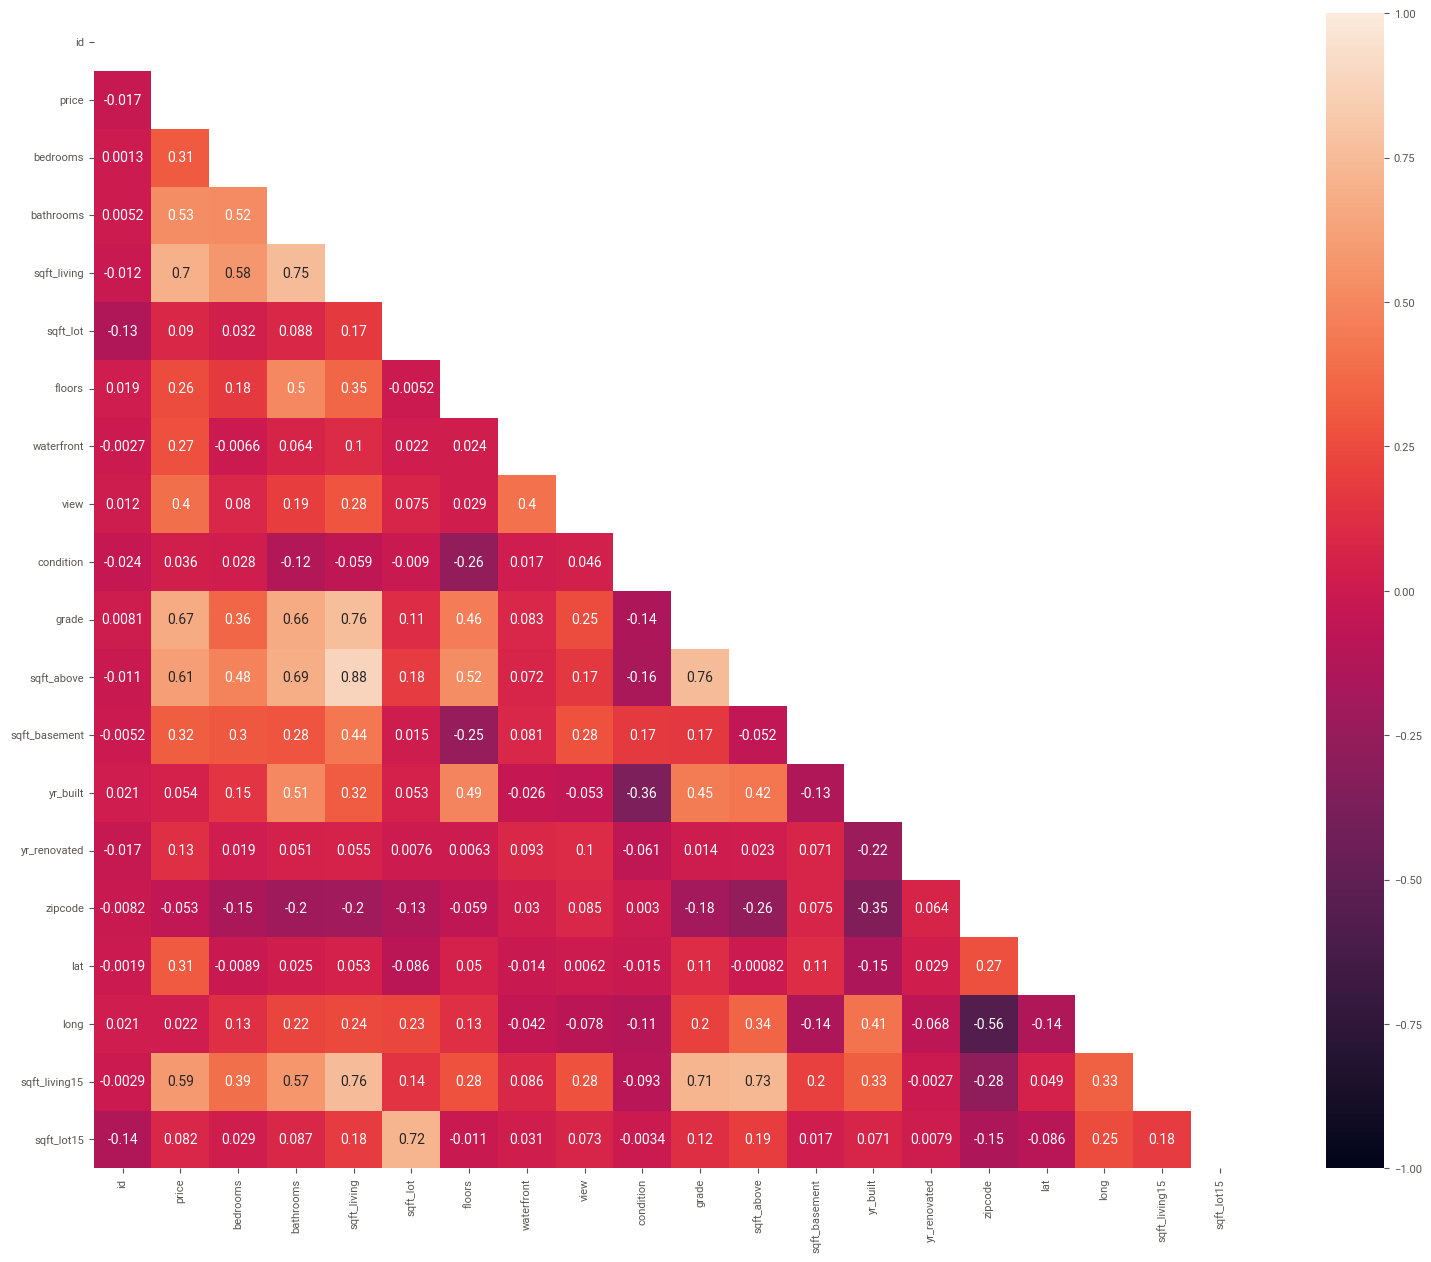

In [16]:
# CORRELATION MATRIX

# Compute the correlation matrix
corr = num_attributes.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(20, 15))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, square = True, annot=True, vmin=-1, vmax=1)



### We can see a strong positive correlation between bathrooms and (sqft_living15,sqft_above,gade and sqft_living)
### and bewteen sqft_living15 to grade and sqft_above

In [17]:
new_num_attributes = num_attributes[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15']].copy()
new_num_attributes

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.00,3,1.00,1180,5650,1.00,3,7,1180,0,1955,98178,47.51,-122.26,1340,5650
1,538000.00,3,2.25,2570,7242,2.00,3,7,2170,400,1951,98125,47.72,-122.32,1690,7639
2,180000.00,2,1.00,770,10000,1.00,3,6,770,0,1933,98028,47.74,-122.23,2720,8062
3,604000.00,4,3.00,1960,5000,1.00,5,7,1050,910,1965,98136,47.52,-122.39,1360,5000
4,510000.00,3,2.00,1680,8080,1.00,3,8,1680,0,1987,98074,47.62,-122.05,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.00,3,2.50,1530,1131,3.00,3,8,1530,0,2009,98103,47.70,-122.35,1530,1509
21609,400000.00,4,2.50,2310,5813,2.00,3,8,2310,0,2014,98146,47.51,-122.36,1830,7200
21610,402101.00,2,0.75,1020,1350,2.00,3,7,1020,0,2009,98144,47.59,-122.30,1020,2007
21611,400000.00,3,2.50,1600,2388,2.00,3,8,1600,0,2004,98027,47.53,-122.07,1410,1287


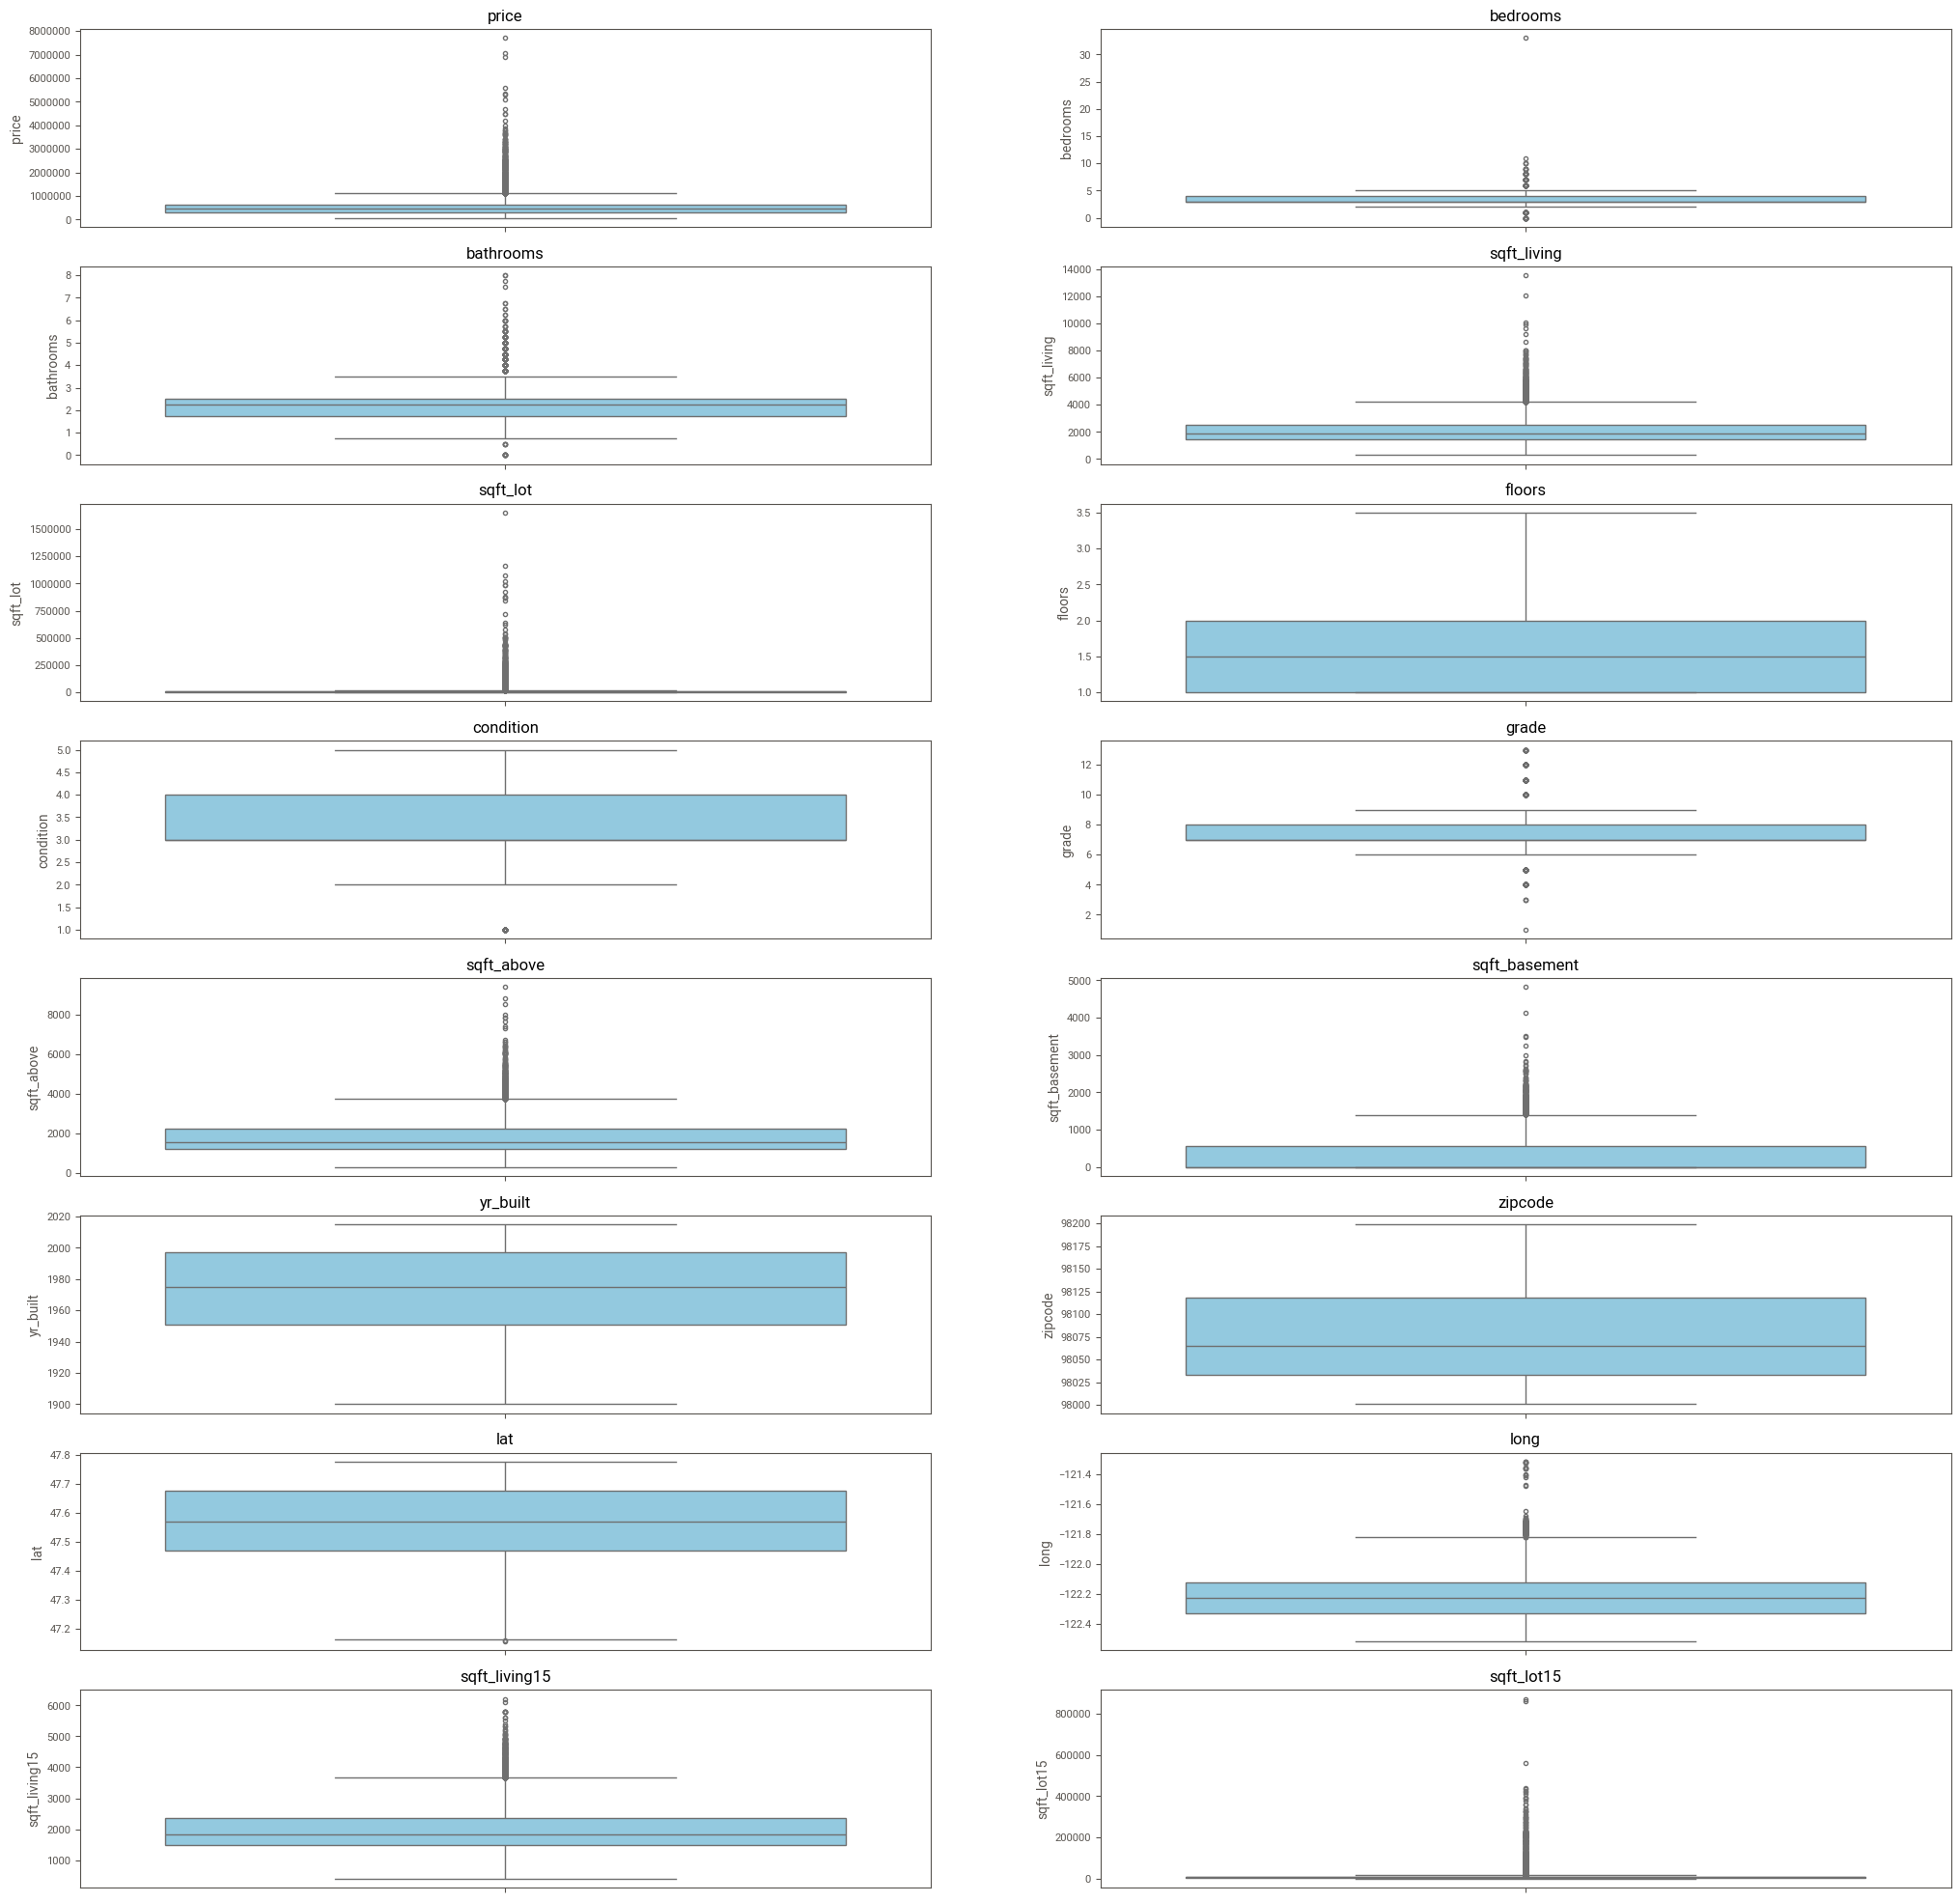

In [18]:
#BoxPlot
fig, axes = plt.subplots(8, 2, figsize=(25, 25))
# Lista com os nomes das colunas e os eixos
colunas = new_num_attributes.columns
eixos = axes.flatten()  # transforma a matriz em uma lista

# boxplots
for i, col in enumerate(colunas):
    sns.boxplot(data=new_num_attributes, y=col, ax=eixos[i], color='skyblue')
    eixos[i].set_title(f'{col}')


plt.show()

## Hypotheses

###  H1: Seasonality: Properties sold during the Summer have a median price at least 10% higher than those sold during the Winter.

In [19]:
#Summer in USA occurs from June to September
df =data.copy()
df['season'] = df['date'].dt.month.apply(lambda x: 'summer' if x in [6,7,8,9] else 'not_summer')
df2 = df.groupby('season')['price'].mean().reset_index()
total_price = df2['price'].sum()
df2['percent'] = df2['price'].apply(lambda x: x/total_price*100)
df2
print('FALSE: Summer percentage of median price is {:.2f}%, which is not +10% more '.format(df2['percent'][1]))

FALSE: Summer percentage of median price is 50.21%, which is not +10% more 


### H2: Waterfront Value: Houses with a waterfront view are, on average, 100% more expensive than those without one.

In [20]:
df = data.copy()
df2=df.groupby('waterfront')['price'].mean().reset_index()
df2['percent'] = df2['price'].apply(lambda x: x/total_price*100)
df2
print('TRUE: Properties with Waterfront view are 3 times more expensive {:.2f}% then the properties which does not have waterfront view  {:.2f}% '.format(df2['percent'][1],df2['percent'][0]))

TRUE: Properties with Waterfront view are 3 times more expensive 153.69% then the properties which does not have waterfront view  49.16% 


### H3: Renovation Impact: Properties that have been renovated have a median price 20% higher than properties that have never been renovated.

In [21]:
df = data.copy()
df['renovated'] =df.apply(lambda x: 'yes' if x['yr_renovated'] >0 else 'no', axis=1)
df2=df.groupby('renovated')['price'].mean().reset_index()
df2['percent'] = df2['price'].apply(lambda x: x/total_price*100)
df2
print('TRUE: Properties which was renovated have {:.2f}% while perperties which were not renovated has {:.2f}%, in other words 20% more. '.format(df2['percent'][1],df2['percent'][0]))

TRUE: Properties which was renovated have 70.32% while perperties which were not renovated has 49.05%, in other words 20% more. 


### H4: Basement Influence: Houses with a basement are more expensive than houses without one, regardless of the total living square footage.

In [22]:
df = data.copy()
df['sqft_basement'] =df.apply(lambda x: 'yes' if x['sqft_basement'] >0 else 'no', axis=1)
df2=df.groupby('sqft_basement')['price'].mean().reset_index()
df2['percent'] = df2['price'].apply(lambda x: x/total_price*100)
df2
print('TRUE: Properties which has basement are more expensive {:.2f}% than perperties which does not have basement {:.2f}% '.format(df2['percent'][1],df2['percent'][0]))

TRUE: Properties which has basement are more expensive 57.56% than perperties which does not have basement 45.03% 


### H5: Age vs. Price: Properties built before 1950 are cheaper than those built after 1950.

In [23]:
df = data.copy()
df['age'] =df.apply(lambda x: 'yes' if x['yr_built'] <1950 else 'no', axis=1)
df2=df.groupby('age')['price'].mean().reset_index()
df2['percent'] = df2['price'].apply(lambda x: x/total_price*100)
df2
print('FALSE: Properties aged <1950 are not cheaper {:.2f}% than perperties aged >1950 {:.2f}%, but the difference is insignificant. '.format(df2['percent'][1],df2['percent'][0]))


FALSE: Properties aged <1950 are not cheaper 50.55% than perperties aged >1950 49.77%, but the difference is insignificant. 


### H6: Condition vs. Price: Houses in "Excellent" condition (level 5) are at least 30% more expensive than those in "Fair" condition (level 3).

In [24]:
df = data.copy()
df1 = df.loc[(data['condition'] == 3) | (data['condition'] == 5)]
df1
df2 = df1.groupby('condition')['price'].mean().reset_index()
df2['percent'] = df2['price'].apply(lambda x: x/total_price*100)
df2
print('FALSE: Properties in excellent condition {:.2f}% are no  30% expensive than perperties in fair condition {:.2f}%. '.format(df2['percent'][1],df2['percent'][0]))


FALSE: Properties in excellent condition 56.64% are no  30% expensive than perperties in fair condition 50.13%. 


# CEO Questions

## Data Overview

### 1. How many houses are available for purchase?

In [25]:
print("There are {} houses".format(data.shape[0]))

There are 21613 houses


### 2. How many attributes do the houses have?

In [26]:
print("There are {} attributes for the houses".format(data.shape[1]))

There are 21 attributes for the houses


### 3. What are the attributes of the houses?

In [27]:
attr = list(data.columns)
print ( 'the attributes are:')
for i in attr:
    print(i)

the attributes are:
id
date
price
bedrooms
bathrooms
sqft_living
sqft_lot
floors
waterfront
view
condition
grade
sqft_above
sqft_basement
yr_built
yr_renovated
zipcode
lat
long
sqft_living15
sqft_lot15


### 4. Which is the most expensive house (the house with the highest selling price)?

In [28]:
#print("The most expesnive house cost: {}".format(data['price'].max()))
var=data[['id','price']].sort_values('price',ascending=False).iloc[0]
print("The most expenside house has ID {} and cost {}".format(var["id"],var["price"]))

The most expenside house has ID 6762700020.0 and cost 7700000.0


### 5. Which house has the highest number of bedrooms?

In [29]:
var = data[['id','bedrooms']].sort_values('bedrooms',ascending=False).iloc[0]
print("Highest number of bedrooms belong to ID {} with {} bedrooms.".format(var['id'],var['bedrooms']))

Highest number of bedrooms belong to ID 2402100895 with 33 bedrooms.


### 6. What is the total number of bedrooms in the dataset?

In [30]:
var = data['bedrooms'].sum()
print("Total of bedroom is {}.".format(var))

Total of bedroom is 72854.


### 7. How many houses have 2 bathrooms?

In [31]:
#3 ways
var = data[['bathrooms']][data['bathrooms']==2].count()
var1 = data.query('bathrooms==2').count().iloc[1]
var2 =data[(data.bathrooms == 2)].count().iloc[1]
print("Total of houses with 2 bathrooms is {}.".format(var))
print("Total of houses with 2 bathrooms is {}.".format(var1))
print("Total of houses with 2 bathrooms is {}.".format(var2))

Total of houses with 2 bathrooms is bathrooms    1930
dtype: int64.
Total of houses with 2 bathrooms is 1930.
Total of houses with 2 bathrooms is 1930.


### 8. How many houses have more than 2 floors?

In [32]:
#3 ways
var = data[['floors']][data['floors']>2].count()
var1 = data.query('floors > 2').count().iloc[1]
var2 =data[(data.floors> 2)].count().iloc[1]
print("Total of houses with more than 2 floors is {}.".format(var))
print("Total of houses with more than 2 floors is {}.".format(var1))
print("Total of houses with more than 2 floors is {}.".format(var2))

Total of houses with more than 2 floors is floors    782
dtype: int64.
Total of houses with more than 2 floors is 782.
Total of houses with more than 2 floors is 782.


### 9. How many houses have a sea view?

In [33]:
#3 ways
var = data[['waterfront']][data['waterfront']==1].count()
var1 = data.query('waterfront == 1').count().iloc[1]
var2 =data[(data.waterfront == 1)].count().iloc[1]
print("Total of houses with waterfront is {}.".format(var))
print("Total of houses with waterfront is {}.".format(var1))
print("Total of houses with  waterfront {}.".format(var2))

Total of houses with waterfront is waterfront    163
dtype: int64.
Total of houses with waterfront is 163.
Total of houses with  waterfront 163.


### 10. Among the houses with a sea view, how many have 3 bedrooms?

In [34]:
var = data.query('waterfront == 1')
var1 =var.query('bedrooms ==3').count().iloc[0]
print("Total of houses with  waterfront and 3 bedrooms is {}.".format(var1))


Total of houses with  waterfront and 3 bedrooms is 64.


### 11. What is the average price of all houses in the dataset?

In [35]:
var = data['price'].mean()
var
print("Average price of all houses in the dataset is {}.".format(var))


Average price of all houses in the dataset is 540088.1417665294.


### 12. What is the average price of houses with 2 bathrooms?

In [36]:
var = data[data['bathrooms'] == 2]

print("Average price of houses with 2 bathrooms is {}.".format(var['price'].mean()))

Average price of houses with 2 bathrooms is 457889.7186528497.


### 13. What is the minimum price among houses with 3 bedrooms?

In [37]:
var  = data[(data.bedrooms == 3)]
print("The minimum price for house with 3 bedroomsis {}.".format(var['price'].min()))

The minimum price for house with 3 bedroomsis 82000.0.


### 14. How many houses have more than 300 square meters of living room area?

In [38]:
var = data.query('sqft_living15 > 300')
print("The amount of house with with more than 300 square meters is {}.".format(var.count().iloc[0]))

The amount of house with with more than 300 square meters is 21613.


### 15. Among the houses with more than 300 square meters of living room area, how many have more than 2 bathrooms?

In [39]:
var = data.query('sqft_living15 > 300 & bathrooms >2')
print("The amount of house with with more than 300 square meters and more than 2 bathrooms is {}.".format(var.count().iloc[0]))

The amount of house with with more than 300 square meters and more than 2 bathrooms is 11242.


### 16. What is the date of the oldest property in the portfolio?

In [40]:
var  = data.sort_values('date', ascending=True)
print( var['date'].iloc[0])

2014-05-02 00:00:00


### 17. How many properties have the maximum number of floors?

In [41]:
#first method
floor_list = list(data['floors'].unique())
floor_list_max = max(floor_list)
floor_list_max
var = data.query('floors == @floor_list_max').count().iloc[0]
var
print("First method: The amount of properties with maximum number of floors is {}.".format(var))
#second method

#retorna apenas as linhas verdadeiras
#print(data[data['floors']==3.5][['floors','id']])
#traz o numero de linhas e colunas
var1 = data[data['floors']==3.5][['floors','id']].shape[0]
print("Second method: The amount of properties with maximum number of floors is {}.".format(var1))


First method: The amount of properties with maximum number of floors is 8.
Second method: The amount of properties with maximum number of floors is 8.


### 18. Create a classification for properties, separating them into low-end and high-end categories based on price:

- Above R$540,000 → **High-end**
- Below R$540,000 → **Low-end**

In [42]:
#Creating a new column
data['level'] = 'to_definev'
data.loc[data['price'] >540000, ['level']]= 'high_level'
data.loc[data['price'] <540000, ['level']]= 'low_level'
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,level
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,1180,0,1955,0,98178,47.51,-122.26,1340,5650,low_level
1,6414100192,2014-12-09,538000.00,3,2.25,2570,7242,2.00,0,0,...,2170,400,1951,1991,98125,47.72,-122.32,1690,7639,low_level
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,770,0,1933,0,98028,47.74,-122.23,2720,8062,low_level
3,2487200875,2014-12-09,604000.00,4,3.00,1960,5000,1.00,0,0,...,1050,910,1965,0,98136,47.52,-122.39,1360,5000,high_level
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,1680,0,1987,0,98074,47.62,-122.05,1800,7503,low_level


### 19. Property Report Ordered by Price

I would like a report sorted by price containing the following information:

- Property ID  
- Date the property became available for purchase  
- Number of bedrooms  
- Lot size (sqtf_lot)  
- Price  
- Property classification (high-end or low-end)


In [43]:
report= data[['id','date','price','bedrooms','sqft_lot','level']]
report=report.sort_values('price',ascending=False)
# salving as .csv
report.to_csv('datasets/report_question19.csv', index=False) #index false reseta o indice

### 20. Property Locations Map

Create a map displaying the geographic distribution of properties based on their latitude and longitude.


In [44]:

data_mapa=data[['id','lat','long','price']]
lat_center = data_mapa['lat'].mean()
lon_center = data_mapa['long'].mean()
print(data_mapa)
mapa=px.scatter_map(data_mapa, lat='lat',lon='long', hover_name='id',
                hover_data=['price'],color_discrete_sequence=['fuchsia'],
                zoom=9, center={'lat': lat_center, 'lon': lon_center}, height=300)

 #desenhando o layout do mapa
mapa.update_layout(mapbox_style='open-street-map')
mapa.update_layout(height=600,margin={'r':0,'t':0,'l':0,'b':0})#right,top,left,bottom
mapa.show()
mapa.write_html('datasets/mapa_house_rocket.html')

               id   lat    long     price
0      7129300520 47.51 -122.26 221900.00
1      6414100192 47.72 -122.32 538000.00
2      5631500400 47.74 -122.23 180000.00
3      2487200875 47.52 -122.39 604000.00
4      1954400510 47.62 -122.05 510000.00
...           ...   ...     ...       ...
21608   263000018 47.70 -122.35 360000.00
21609  6600060120 47.51 -122.36 400000.00
21610  1523300141 47.59 -122.30 402101.00
21611   291310100 47.53 -122.07 400000.00
21612  1523300157 47.59 -122.30 325000.00

[21613 rows x 4 columns]


### 21. Create a new column called: `house_age`

- If the value in the `date` column is greater than `2014-01-01` → `'new_house'`
- If the value in the `date` column is less than `2014-01-01` → `'old_house'`

In [45]:
data['house_age'] ="to_define"
data.loc[data['date'] >"2014-01-01", 'house_age']= 'new_house'
data.loc[data['date'] <"2014-01-01", 'house_age']= 'old_house'
data
var1 = data.query("house_age == 'new_house'")
var2 = data.loc[data['house_age'] == 'new_house']
var2

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,level,house_age
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,0,1955,0,98178,47.51,-122.26,1340,5650,low_level,new_house
1,6414100192,2014-12-09,538000.00,3,2.25,2570,7242,2.00,0,0,...,400,1951,1991,98125,47.72,-122.32,1690,7639,low_level,new_house
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,0,1933,0,98028,47.74,-122.23,2720,8062,low_level,new_house
3,2487200875,2014-12-09,604000.00,4,3.00,1960,5000,1.00,0,0,...,910,1965,0,98136,47.52,-122.39,1360,5000,high_level,new_house
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,0,1987,0,98074,47.62,-122.05,1800,7503,low_level,new_house
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.00,3,2.50,1530,1131,3.00,0,0,...,0,2009,0,98103,47.70,-122.35,1530,1509,low_level,new_house
21609,6600060120,2015-02-23,400000.00,4,2.50,2310,5813,2.00,0,0,...,0,2014,0,98146,47.51,-122.36,1830,7200,low_level,new_house
21610,1523300141,2014-06-23,402101.00,2,0.75,1020,1350,2.00,0,0,...,0,2009,0,98144,47.59,-122.30,1020,2007,low_level,new_house
21611,291310100,2015-01-16,400000.00,3,2.50,1600,2388,2.00,0,0,...,0,2004,0,98027,47.53,-122.07,1410,1287,low_level,new_house


### 22. Create a new column called: `dormitory_type`

- If the value in the `bedrooms` column is equal to 1 → `'studio'`
- If the value in the `bedrooms` column is equal to 2 → `'apartment'`
- If the value in the `bedrooms` column is greater than 2 → `'house'`

In [46]:
data['dormitory_type'] ="to_define"
data.loc[data['bedrooms'] ==1, 'dormitory_type']= 'studio'
data.loc[data['bedrooms'] ==2, 'dormitory_type']= 'apartment'
data.loc[data['bedrooms'] >2, 'dormitory_type']= 'house'
print(data.head(10))

           id       date      price  bedrooms  bathrooms  sqft_living  \
0  7129300520 2014-10-13  221900.00         3       1.00         1180   
1  6414100192 2014-12-09  538000.00         3       2.25         2570   
2  5631500400 2015-02-25  180000.00         2       1.00          770   
3  2487200875 2014-12-09  604000.00         4       3.00         1960   
4  1954400510 2015-02-18  510000.00         3       2.00         1680   
5  7237550310 2014-05-12 1225000.00         4       4.50         5420   
6  1321400060 2014-06-27  257500.00         3       2.25         1715   
7  2008000270 2015-01-15  291850.00         3       1.50         1060   
8  2414600126 2015-04-15  229500.00         3       1.00         1780   
9  3793500160 2015-03-12  323000.00         3       2.50         1890   

   sqft_lot  floors  waterfront  view  ...  yr_built  yr_renovated  zipcode  \
0      5650    1.00           0     0  ...      1955             0    98178   
1      7242    2.00           0     0 

### 23. Create a new column called: `condition_type`

- If the value in the `condition` column is less than or equal to 2 → `'bad'`
- If the value in the `condition` column is equal to 3 or 4 → `'regular'`
- If the value in the `condition` column is equal to 5 → `'good'`

In [47]:
data['condition_type'] ="to_define"
data.loc[data['condition'] ==2, 'condition_type']= 'bad'
data.loc[data['condition'] ==3, 'condition_type']= 'regular'
data.loc[data['condition'] ==4, 'condition_type']= 'regular'
data.loc[data['condition'] ==5, 'condition_type']= 'good'
print(data.head(20))
print(data.dtypes)

            id       date      price  bedrooms  bathrooms  sqft_living  \
0   7129300520 2014-10-13  221900.00         3       1.00         1180   
1   6414100192 2014-12-09  538000.00         3       2.25         2570   
2   5631500400 2015-02-25  180000.00         2       1.00          770   
3   2487200875 2014-12-09  604000.00         4       3.00         1960   
4   1954400510 2015-02-18  510000.00         3       2.00         1680   
5   7237550310 2014-05-12 1225000.00         4       4.50         5420   
6   1321400060 2014-06-27  257500.00         3       2.25         1715   
7   2008000270 2015-01-15  291850.00         3       1.50         1060   
8   2414600126 2015-04-15  229500.00         3       1.00         1780   
9   3793500160 2015-03-12  323000.00         3       2.50         1890   
10  1736800520 2015-04-03  662500.00         3       2.50         3560   
11  9212900260 2014-05-27  468000.00         2       1.00         1160   
12   114101516 2014-05-28  310000.00  

### 24. Change the data type of the `condition` column to STRING

In [48]:
data['condition']=data['condition'].astype(str)
print(data.dtypes)

id                         int64
date              datetime64[ns]
price                    float64
bedrooms                   int64
bathrooms                float64
sqft_living                int64
sqft_lot                   int64
floors                   float64
waterfront                 int64
view                       int64
condition                 object
grade                      int64
sqft_above                 int64
sqft_basement              int64
yr_built                   int64
yr_renovated               int64
zipcode                    int64
lat                      float64
long                     float64
sqft_living15              int64
sqft_lot15                 int64
level                     object
house_age                 object
dormitory_type            object
condition_type            object
dtype: object


### 25. Delete the columns: `sqft_living15` and `sqft_lot15`

In [49]:
cols=["sqft_living15","sqft_lot15"]
data=data.drop(cols, axis=1) # axis=1 -> deleta as linhas ao longo das colunas
print(data.columns)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'level', 'house_age', 'dormitory_type',
       'condition_type'],
      dtype='object')


### 26. Change the data type of the `yr_built` column to DATE

In [50]:

data['yr_built'] = pd.to_datetime( data['yr_built'], format="%Y", errors= 'coerce') # coerce vira NAT (Not a time)
var1 = data['yr_built'].isna().sum()
print('There are {} lines without a year'.format(var1))

There are 0 lines without a year


### 27. Change the data type of the `yr_renovated` column to DATE

In [51]:
data['yr_renovated'] = pd.to_datetime( data['yr_renovated'], format="%Y", errors= 'coerce')#datetime sempre cria um obeto datetime completo, vai retornar ano, mes dia e hora
#print(data.dtypes)
data['yr_renovated'] = data['yr_renovated'].dt.year
#data['yr_renovated'] = data['yr_renovated'].dt.to_period('Y')
var1 = data['yr_renovated'].isna().sum()
print('There are {} lines without a year renovated info'.format(var1))
data['yr_renovated'].unique()

There are 20699 lines without a year renovated info


array([  nan, 1991., 2002., 2010., 1999., 1992., 2013., 1994., 1978.,
       2005., 2008., 2003., 1984., 1954., 2014., 2011., 1974., 1983.,
       1945., 1990., 1988., 1957., 1977., 1981., 1995., 2000., 1998.,
       1970., 1989., 2004., 1986., 2009., 2007., 1987., 1973., 2006.,
       1985., 2001., 1980., 1971., 1979., 1997., 1950., 1969., 1948.,
       2015., 1968., 2012., 1963., 1951., 1993., 1962., 1996., 1972.,
       1953., 1955., 1982., 1956., 1940., 1976., 1946., 1975., 1958.,
       1964., 1959., 1960., 1967., 1965., 1934., 1944.])

### 28. What is the oldest construction year of a property?

In [52]:
var = data[['yr_built']].sort_values('yr_built',ascending=True).iloc[0]
var

yr_built   1900-01-01
Name: 4697, dtype: datetime64[ns]

### 29. What is the oldest renovation year of a property?

In [53]:
var = data.loc[data['yr_renovated'].notna()]
var1=var[['yr_renovated']].sort_values('yr_renovated',ascending=True)
#print(var1)
#data.loc[data['id']==6414100192]
var1.iloc[0]


yr_renovated   1934.00
Name: 13736, dtype: float64

### 30. How many properties have 2 floors?

In [54]:
data.loc[data['floors'] ==2].shape[0]

8241

### 31. How many properties have the condition equal to `"regular"`?

In [55]:
print(data[data['condition_type']=="regular"][['condition_type','id']])

      condition_type          id
0            regular  7129300520
1            regular  6414100192
2            regular  5631500400
4            regular  1954400510
5            regular  7237550310
...              ...         ...
21608        regular   263000018
21609        regular  6600060120
21610        regular  1523300141
21611        regular   291310100
21612        regular  1523300157

[19710 rows x 2 columns]


### 32. How many properties have the condition equal to `"bad"` and have a `"waterfront view"`?

In [56]:
bad_type=data[data['condition_type']=="bad"]
bad_waterfront=bad_type[bad_type['waterfront']==1][['condition_type','waterfront']]
print(bad_waterfront.shape[0])

1


### 33. How many properties have the condition equal to `"good"` and are classified as `"new_house"`?

In [57]:
good_condition=data[data['condition_type']=="good"]
print(good_condition[good_condition['house_age']=="new_house"][['condition_type','house_age']])

      condition_type  house_age
3               good  new_house
25              good  new_house
27              good  new_house
49              good  new_house
62              good  new_house
...              ...        ...
19604           good  new_house
19620           good  new_house
19873           good  new_house
19905           good  new_house
21303           good  new_house

[1701 rows x 2 columns]


### 34. What is the highest price of a `"studio"` type property?

In [58]:
studio_dormitory_type=data[data['dormitory_type']=="studio"]
print( studio_dormitory_type['price'].sort_values(ascending=False).iloc[0])

1247000.0


### 35. How many `"apartment"` properties were renovated in 2015?

In [59]:
var = data[data['dormitory_type']=="apartment"]
#print(apartment_dormitory_type)
var2 = var[var['yr_renovated']==2015]
var2

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,level,house_age,dormitory_type,condition_type


### 36. What is the maximum number of bedrooms that a `"house"` type property has?

In [60]:
var=data[data['dormitory_type']=="house"]
var1=var['bedrooms'].sort_values(ascending=False)
print(var1.iloc[0])

33


### 37. How many `"new_house"` properties were renovated in the year 2014?

In [61]:
new_house=data[data['yr_renovated']==2014]
print(new_house[new_house['house_age']=="new_house"])

               id       date      price  bedrooms  bathrooms  sqft_living  \
379    7132300695 2015-04-21  435000.00         3       1.50         1300   
435    2268400350 2014-09-16  749000.00         4       2.50         1710   
891    1962200435 2014-11-10 1010000.00         4       1.00         1820   
1379   1453600202 2014-05-20  520000.00         4       3.50         2680   
1449   8651430560 2014-05-22  180000.00         3       1.00          870   
...           ...        ...        ...       ...        ...          ...   
19133  7151700360 2014-12-11 1028950.00         5       3.25         2680   
19174  2420069220 2014-12-03  209000.00         3       1.00         1320   
19276  2397100705 2014-07-14 1518630.00         4       4.25         3650   
19593   421059018 2014-11-04  257000.00         3       1.75         1397   
20447  3319500628 2015-02-12  356999.00         3       1.50         1010   

       sqft_lot  floors  waterfront  view  ... sqft_basement   yr_built  \


### 38. Select the columns: `id`, `date`, `price`, `floors`, `zipcode` using:



#### 38.1. Directly by column names  


In [62]:
print(data[["id", "date", "price", "floors", "zipcode"]])

               id       date     price  floors  zipcode
0      7129300520 2014-10-13 221900.00    1.00    98178
1      6414100192 2014-12-09 538000.00    2.00    98125
2      5631500400 2015-02-25 180000.00    1.00    98028
3      2487200875 2014-12-09 604000.00    1.00    98136
4      1954400510 2015-02-18 510000.00    1.00    98074
...           ...        ...       ...     ...      ...
21608   263000018 2014-05-21 360000.00    3.00    98103
21609  6600060120 2015-02-23 400000.00    2.00    98146
21610  1523300141 2014-06-23 402101.00    2.00    98144
21611   291310100 2015-01-16 400000.00    2.00    98027
21612  1523300157 2014-10-15 325000.00    2.00    98144

[21613 rows x 5 columns]


#### 38.2. By column indices  


In [63]:
print(data.iloc[:,[0,1,2,7,16]])

               id       date     price  floors  zipcode
0      7129300520 2014-10-13 221900.00    1.00    98178
1      6414100192 2014-12-09 538000.00    2.00    98125
2      5631500400 2015-02-25 180000.00    1.00    98028
3      2487200875 2014-12-09 604000.00    1.00    98136
4      1954400510 2015-02-18 510000.00    1.00    98074
...           ...        ...       ...     ...      ...
21608   263000018 2014-05-21 360000.00    3.00    98103
21609  6600060120 2015-02-23 400000.00    2.00    98146
21610  1523300141 2014-06-23 402101.00    2.00    98144
21611   291310100 2015-01-16 400000.00    2.00    98027
21612  1523300157 2014-10-15 325000.00    2.00    98144

[21613 rows x 5 columns]



#### 38.3. By row indices and column names  


In [64]:
selected_coluns = data.loc[0:5, ["id", "date", "price", "floors", "zipcode"]]
print(selected_coluns)

           id       date      price  floors  zipcode
0  7129300520 2014-10-13  221900.00    1.00    98178
1  6414100192 2014-12-09  538000.00    2.00    98125
2  5631500400 2015-02-25  180000.00    1.00    98028
3  2487200875 2014-12-09  604000.00    1.00    98136
4  1954400510 2015-02-18  510000.00    1.00    98074
5  7237550310 2014-05-12 1225000.00    1.00    98053


### 39. Save a `.csv` file containing only the columns from item 38

In [65]:
selected_coluns.to_csv('datasets/report_ex38.csv', index=False)

### 40. Change the color of the points on the map from `"pink"` to `"dark green"`

In [66]:
data_mapa=data[['id','lat','long','price']]
lat_center = data_mapa['lat'].mean()
lon_center = data_mapa['long'].mean()
mapa=px.scatter_map(data_mapa, lat='lat',lon='long', hover_name='id',
                hover_data=['price'],color_discrete_sequence=['darkgreen'],
                zoom=9, center={'lat': lat_center, 'lon': lon_center}, height=300)

 #desenhando o layout do mapa
mapa.update_layout(mapbox_style='open-street-map')
mapa.update_layout(height=600,margin={'r':0,'t':0,'l':0,'b':0})#right,top,left,bottom
mapa.show()
mapa.write_html('datasets/mapa_house_rocket.html')

### 41. What is the number of properties by construction year?

In [67]:
data[['id','yr_built']].groupby('yr_built').count().reset_index()

,yr_built,id
0,1900-01-01,87
1,1901-01-01,29
2,1902-01-01,27
3,1903-01-01,46
4,1904-01-01,45
...,...,...
111,2011-01-01,130
112,2012-01-01,170
113,2013-01-01,201
114,2014-01-01,559


### 42. What is the minimum number of bedrooms by property construction year?

In [68]:
data[['bedrooms','yr_built']].groupby('yr_built').min().reset_index()

,yr_built,bedrooms
0,1900-01-01,1
1,1901-01-01,2
2,1902-01-01,2
3,1903-01-01,1
4,1904-01-01,2
...,...,...
111,2011-01-01,1
112,2012-01-01,2
113,2013-01-01,2
114,2014-01-01,1


### 43. What is the highest purchase price for each number of bedrooms?

In [69]:
data[['price','bedrooms']].groupby('bedrooms').max().reset_index()

,bedrooms,price
0,0,1295650.00
1,1,1247000.00
2,2,3278000.00
3,3,3800000.00
4,4,4489000.00
5,5,7062500.00
6,6,7700000.00
7,7,3200000.00
8,8,3300000.00
9,9,1400000.00


### 44. What is the total sum of purchase prices by number of bedrooms?

In [70]:
data[['price','bedrooms']].groupby('bedrooms').sum().reset_index()

,bedrooms,price
0,0,5323550.00
1,1,63210934.00
2,2,1107788602.00
3,3,4580263939.00
4,4,4372957028.00
5,5,1259346326.00
6,6,224541613.00
7,7,36145017.00
8,8,14366000.00
9,9,5363999.00


### 45. What is the total sum of purchase prices by number of bedrooms and bathrooms?

In [71]:
data[['price','bedrooms','bathrooms']].groupby(['bedrooms','bathrooms']).sum().reset_index()

,bedrooms,bathrooms,price
0,0,0.00,3642600.00
1,0,0.75,265000.00
2,0,1.00,228000.00
3,0,1.50,288000.00
4,0,2.50,899950.00
...,...,...,...
139,10,2.00,650000.00
140,10,3.00,660000.00
141,10,5.25,1148000.00
142,11,3.00,520000.00


### 46. What is the average living room size of properties by construction year?

In [72]:
data[['sqft_living','yr_built']].groupby('yr_built').mean().reset_index()

,yr_built,sqft_living
0,1900-01-01,1732.01
1,1901-01-01,1763.62
2,1902-01-01,1919.63
3,1903-01-01,1507.74
4,1904-01-01,1603.18
...,...,...
111,2011-01-01,2313.68
112,2012-01-01,2378.74
113,2013-01-01,2636.59
114,2014-01-01,2615.39


### 47. What is the median living room size of properties by construction year?

In [73]:
data[['sqft_living','yr_built']].groupby('yr_built').median().reset_index()

,yr_built,sqft_living
0,1900-01-01,1540.00
1,1901-01-01,1610.00
2,1902-01-01,1600.00
3,1903-01-01,1505.00
4,1904-01-01,1280.00
...,...,...
111,2011-01-01,2270.00
112,2012-01-01,2237.50
113,2013-01-01,2580.00
114,2014-01-01,2650.00


### 48. What is the standard deviation of the living room size of properties by construction year?

In [74]:
data[['sqft_living','yr_built']].groupby('yr_built').std().reset_index()

,yr_built,sqft_living
0,1900-01-01,732.94
1,1901-01-01,668.23
2,1902-01-01,878.66
3,1903-01-01,469.72
4,1904-01-01,1076.87
...,...,...
111,2011-01-01,804.86
112,2012-01-01,771.43
113,2013-01-01,883.50
114,2014-01-01,893.81


### 49. What is the average growth of property purchase prices by year, by day, and by week of the year?

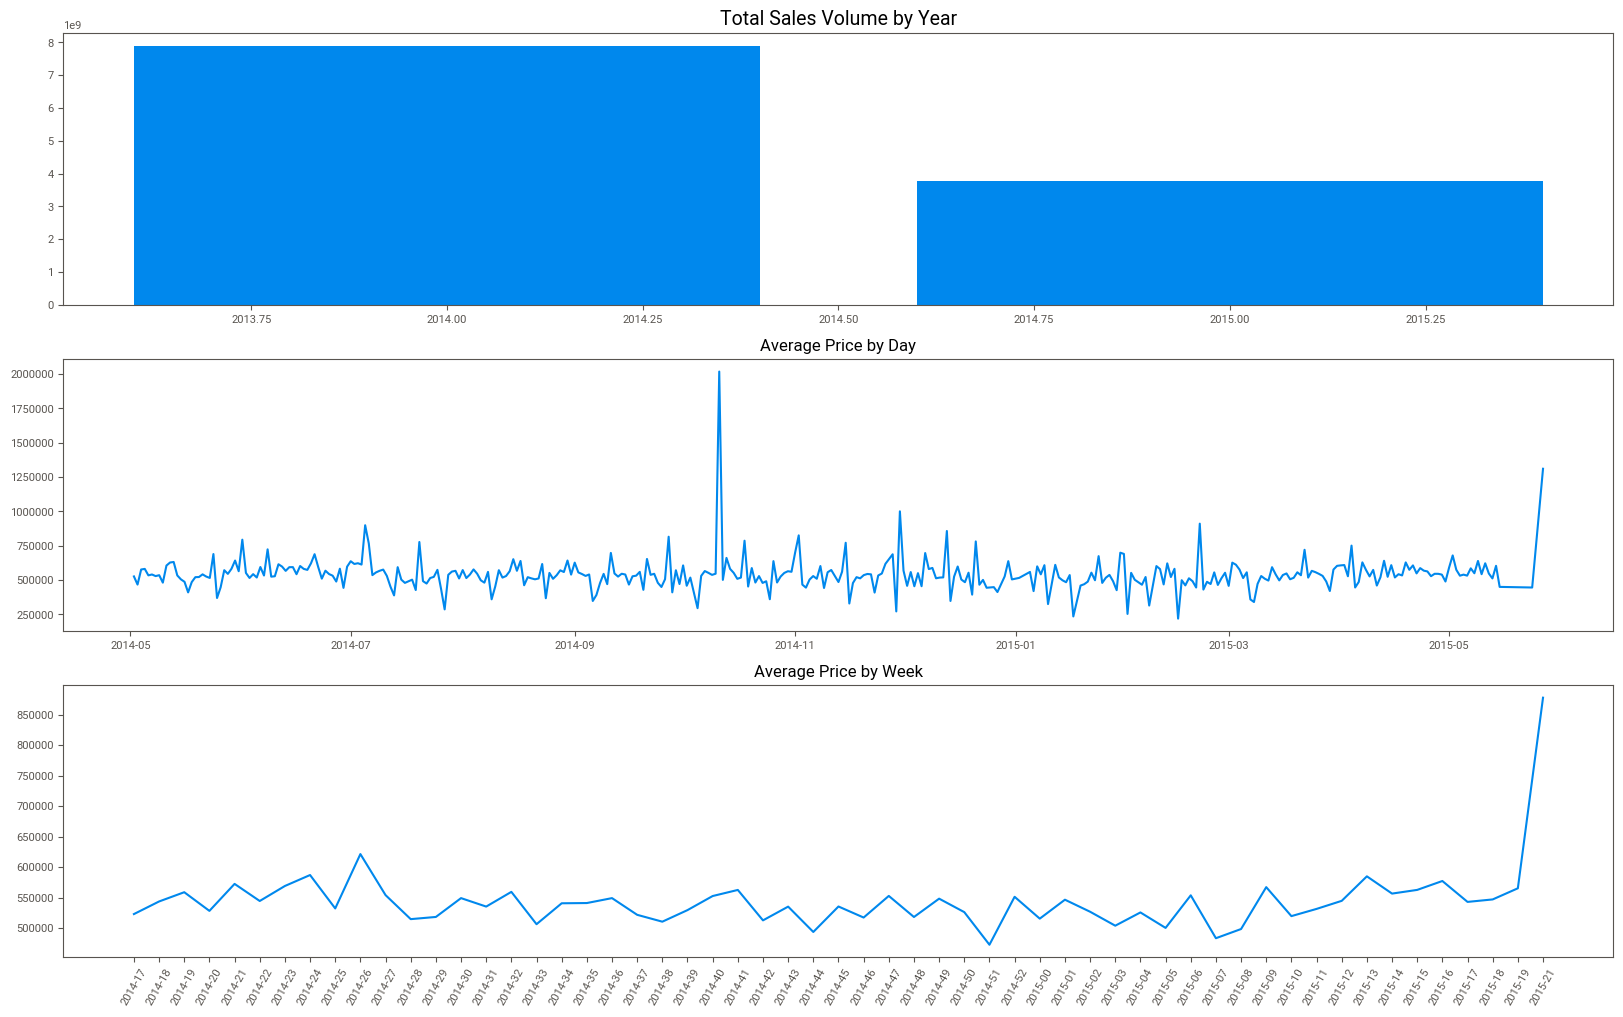

In [75]:
fig=plt.figure(figsize=(20,12))
specs= gridspec.GridSpec(ncols=1,nrows=3,figure=fig)

ax1=fig.add_subplot(specs[0,:])#first row
ax2=fig.add_subplot(specs[1,:]) #second row
ax3=fig.add_subplot(specs[2,:])# third row
#first graph
from matplotlib import pyplot as plt
data['year']=pd.to_datetime(data['date']).dt.year
by_year=data[['price','year']].groupby('year').sum().reset_index()
ax1.bar(by_year['year'],by_year['price'])
ax1.set_title('Total Sales Volume by Year', fontsize=14)

#second graph

data['day']=pd.to_datetime(data['date'])
by_day=data[['price','day']].groupby('day').mean().reset_index()


ax2.plot(by_day['day'],by_day['price'])
ax2.set_title('Average Price by Day', fontsize=12)

#third graph
#%W trás a semana do ano começando na semana e %U começando no domingo 
data['year_week']=pd.to_datetime(data['date']).dt.strftime('%Y-%U')
by_year_week=data[['price','year_week']].groupby('year_week').mean().reset_index()


ax3.plot(by_year_week['year_week'],by_year_week['price'])
ax3.set_title('Average Price by Week', fontsize=12)
plt.xticks(rotation=60);

### 50. I would like to look at the map and identify the houses with the highest prices.

In [76]:
house= data[['id','lat','long','price']]

fig= px.scatter_map( house,
                      lat='lat',
                      lon='long',
                      size ='price',
                      color_continuous_scale=px.colors.cyclical.IceFire,
                      size_max=15,
                      zoom=10)
fig.update_layout(mapbox_style ='open-street-map')
fig.update_layout(height=600,margin={'r':0,'t':0,'l':0,'b':0})
fig.show()

### 51. Create a new column called: `dormitory_type`

- If the value in the `bedrooms` column is equal to 1 → `'studio'`
- If the value in the `bedrooms` column is equal to 2 → `'apartment'`
- If the value in the `bedrooms` column is greater than 2 → `'house'`

In [77]:
data['dormitory_type'] ="to_define"
data.loc[data['bedrooms'] ==1, 'dormitory_type']= 'studio'
data.loc[data['bedrooms'] ==2, 'dormitory_type']= 'apartment'
data.loc[data['bedrooms'] >2, 'dormitory_type']= 'house'

### 52. Create a bar chart representing the sum of prices by number of bedrooms.

<BarContainer object of 13 artists>

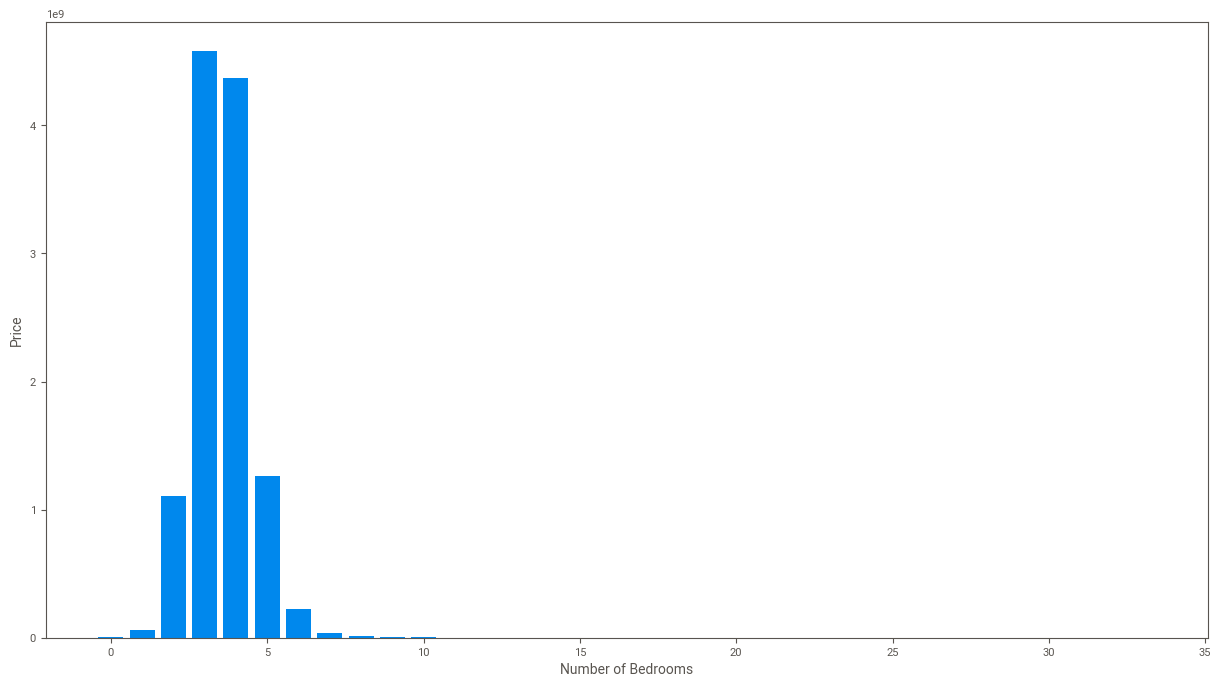

In [78]:
#2. Faça um gráfico de barras que represente a soma dos preços pelo número de quartos.
by_bedrooms=data[['price','bedrooms']].groupby('bedrooms').sum().reset_index()
plt.figure(figsize=(15,8))
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.bar(by_bedrooms['bedrooms'],by_bedrooms['price'])

### 53. Create a line chart representing the average prices by property construction year.

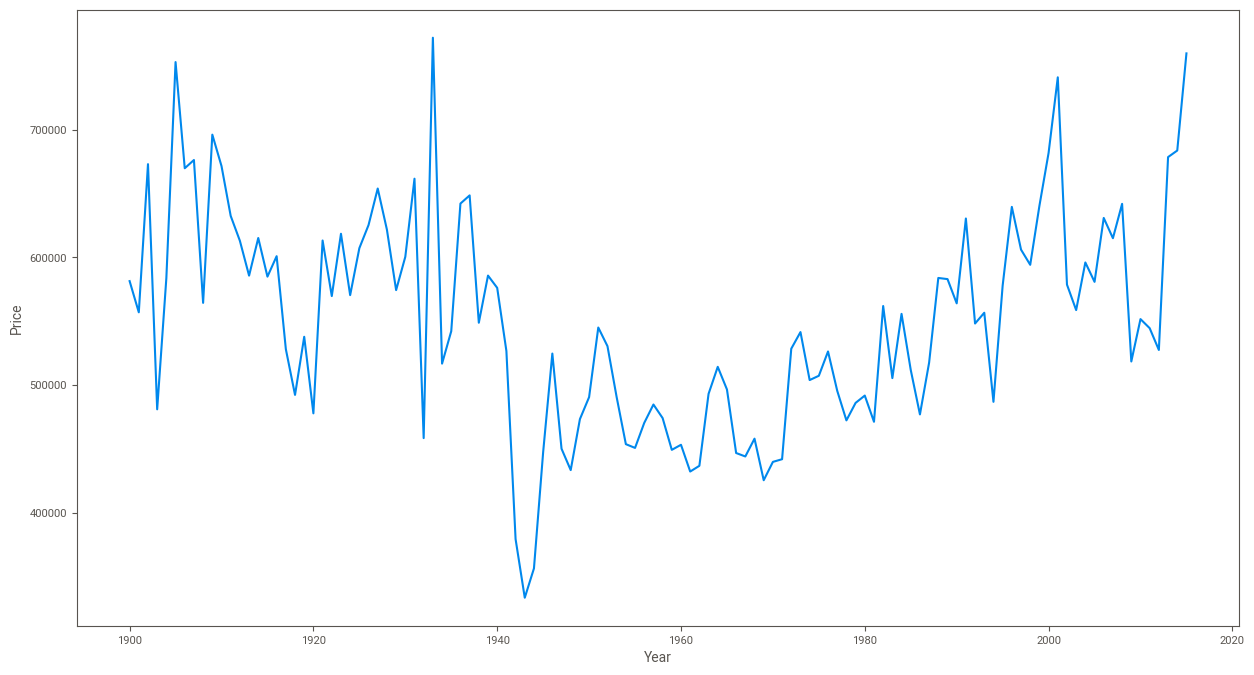

In [79]:
by_yr_built=data[['price','yr_built']].groupby('yr_built').mean().reset_index()
plt.figure(figsize=(15,8))
plt.xlabel('Year')
plt.ylabel('Price')
plt.plot(by_yr_built['yr_built'],by_yr_built['price'])


### 54. Create a bar chart representing the average prices by dormitory type.

<BarContainer object of 4 artists>

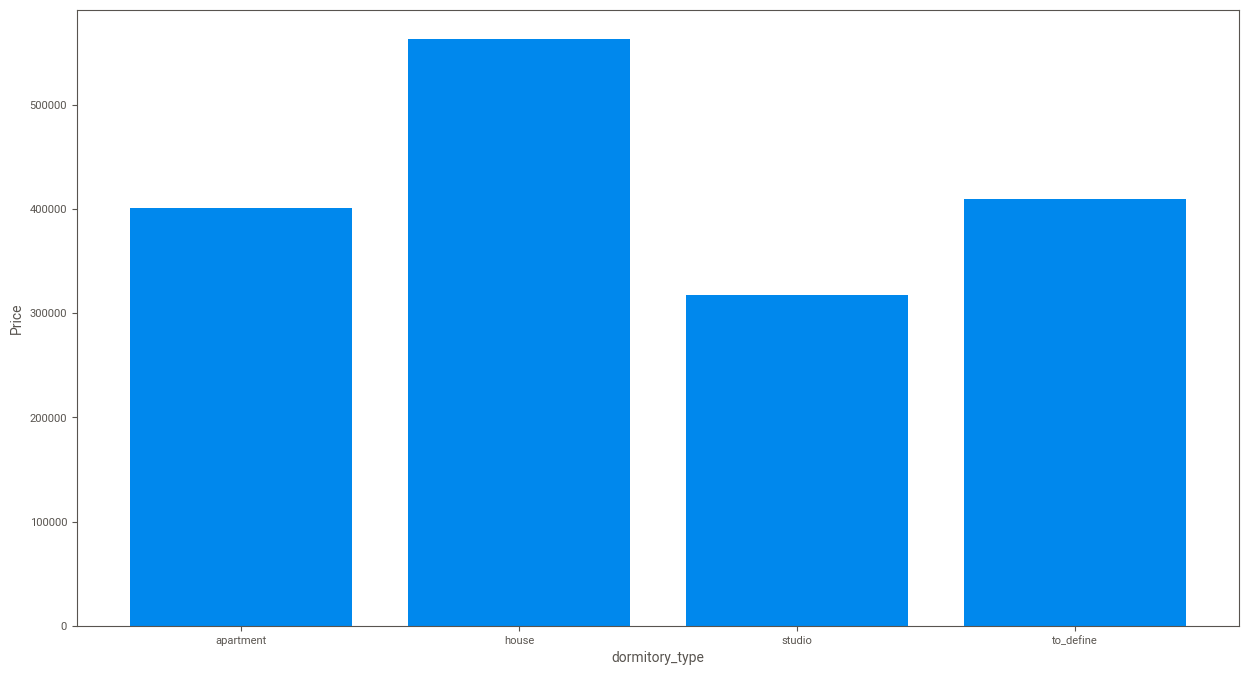

In [80]:
by_dormitory_type=data[['price','dormitory_type']].groupby('dormitory_type').mean().reset_index()
plt.figure(figsize=(15,8))
plt.xlabel('dormitory_type')
plt.ylabel('Price')
plt.bar(by_dormitory_type['dormitory_type'],by_dormitory_type['price'])

### 55. Create a line chart showing the evolution of average prices by renovation year, starting from 1930.

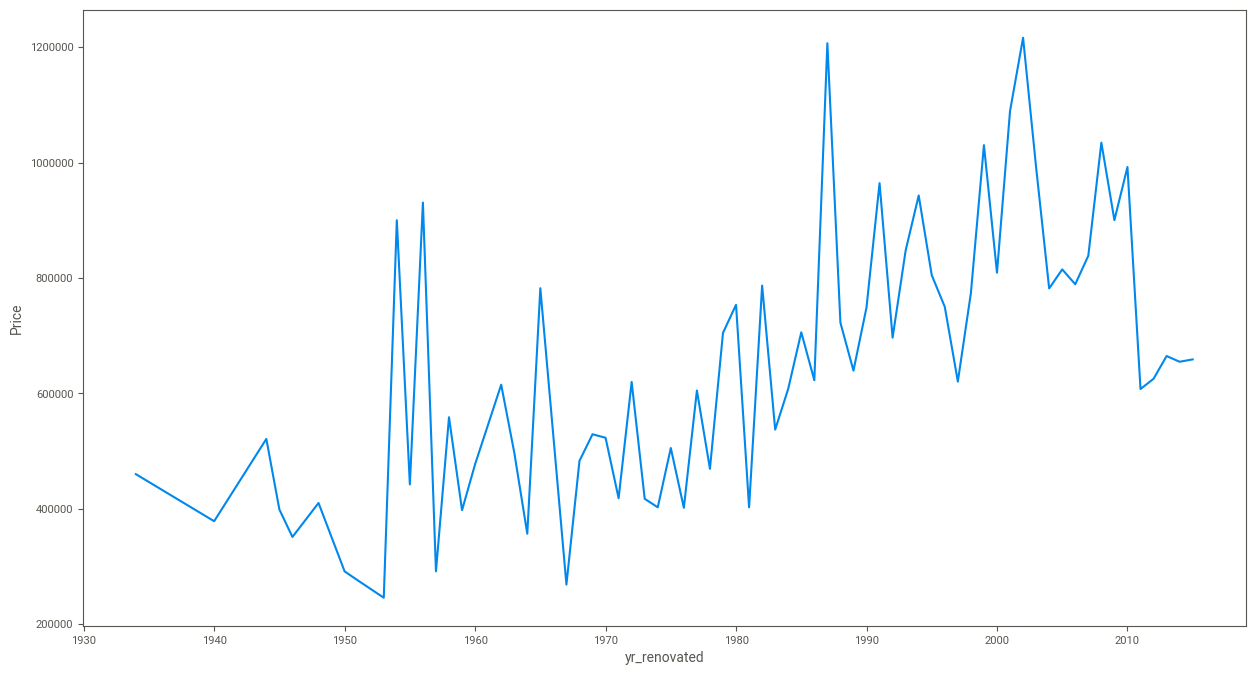

In [81]:
by_yr_renovated=data[['price','yr_renovated']].groupby('yr_renovated').mean().reset_index()
by_yr_renovated
by_yr_renovated.head()
plt.figure(figsize=(15,8))
plt.xlabel('yr_renovated')
plt.ylabel('Price')
plt.plot(by_yr_renovated['yr_renovated'],by_yr_renovated['price'])


### 56. Create a table showing the average prices by construction year and dormitory type.

In [82]:
data[['price','yr_built','dormitory_type']].groupby(['yr_built','dormitory_type']).mean().reset_index()

,yr_built,dormitory_type,price
0,1900-01-01,apartment,589533.33
1,1900-01-01,house,584854.27
2,1900-01-01,studio,398944.00
3,1901-01-01,apartment,452856.40
4,1901-01-01,house,578619.17
...,...,...,...
309,2014-01-01,house,692687.72
310,2014-01-01,studio,516500.00
311,2015-01-01,apartment,543250.00
312,2015-01-01,house,797383.06



### 57. Create a dashboard with the charts from questions 52, 53, and 54  
(Dashboard layout: 1 row and 2 columns)

Text(0, 0.5, 'Total Price')

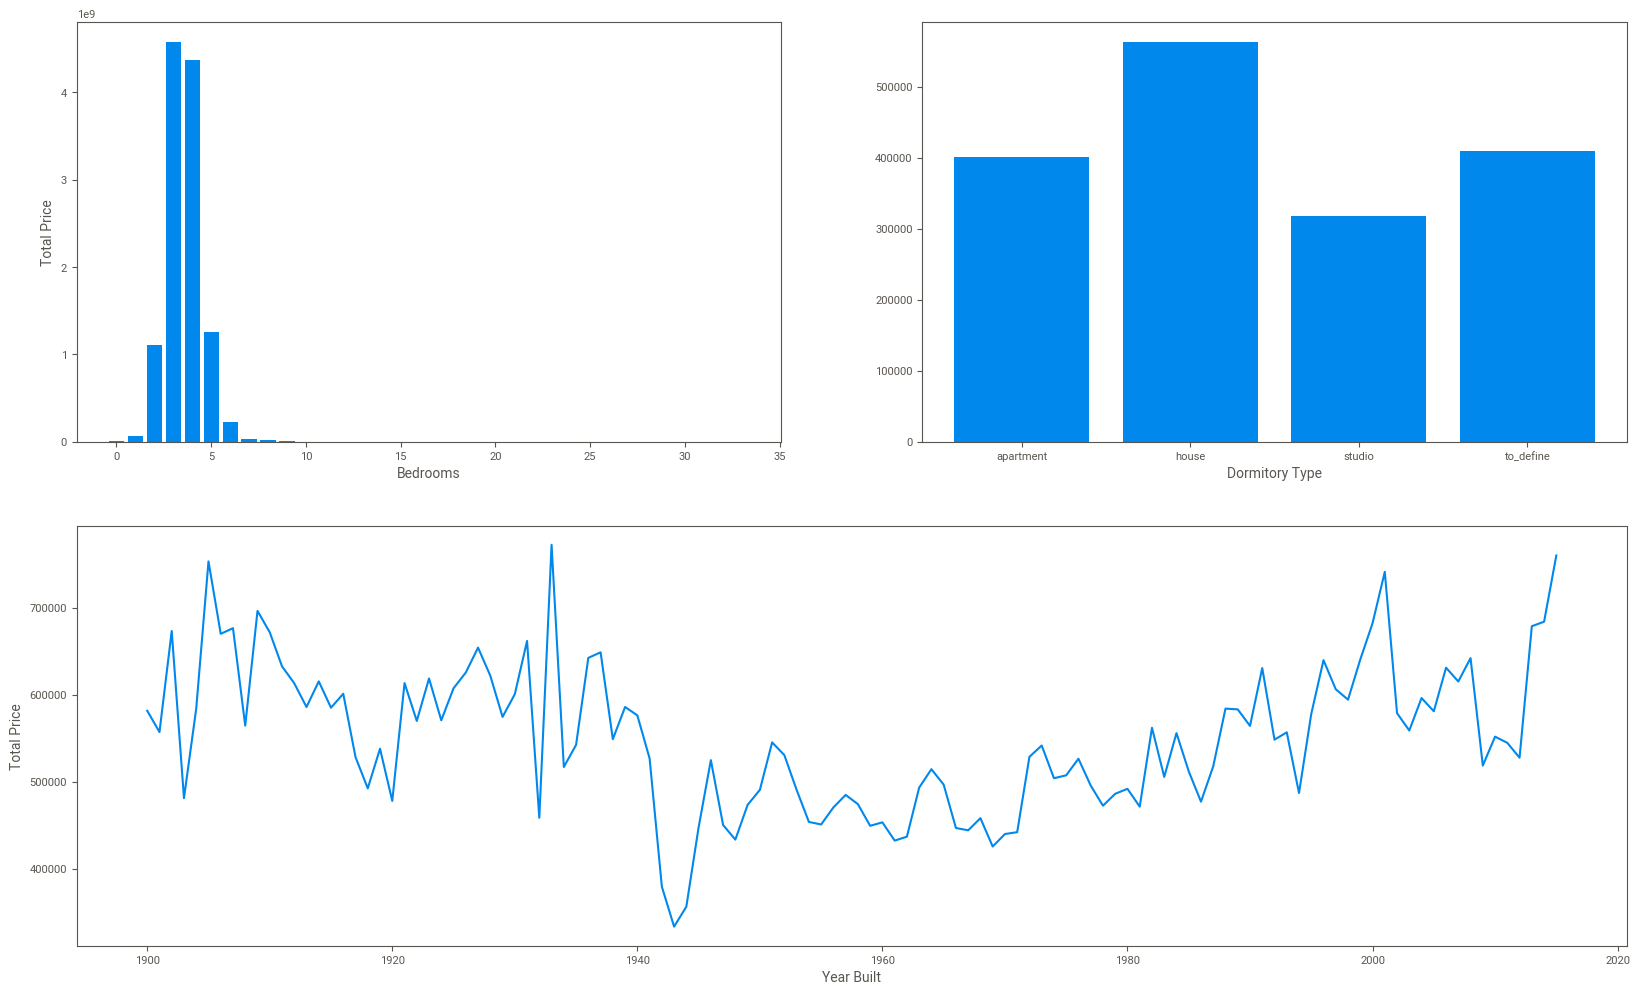

In [83]:
fig=plt.figure(figsize=(20,12))
specs= gridspec.GridSpec(ncols=2,nrows=2,figure=fig)

ax1=fig.add_subplot(specs[0,0])#first col
ax2=fig.add_subplot(specs[0,1]) #second row- first column
ax3=fig.add_subplot(specs[1,:])#second row -second column
ax1.bar(by_bedrooms['bedrooms'],by_bedrooms['price'])
ax1.set_xlabel('Bedrooms')
ax1.set_ylabel('Total Price')
ax2.bar(by_dormitory_type['dormitory_type'],by_dormitory_type['price'])
ax2.set_xlabel('Dormitory Type')
ax3.plot(by_yr_built['yr_built'],by_yr_built['price'])
ax3.set_xlabel('Year Built')
ax3.set_ylabel('Total Price')

### 58. Create a dashboard with the charts from questions 52 and 54  
(Dashboard layout: 2 columns)

<BarContainer object of 4 artists>

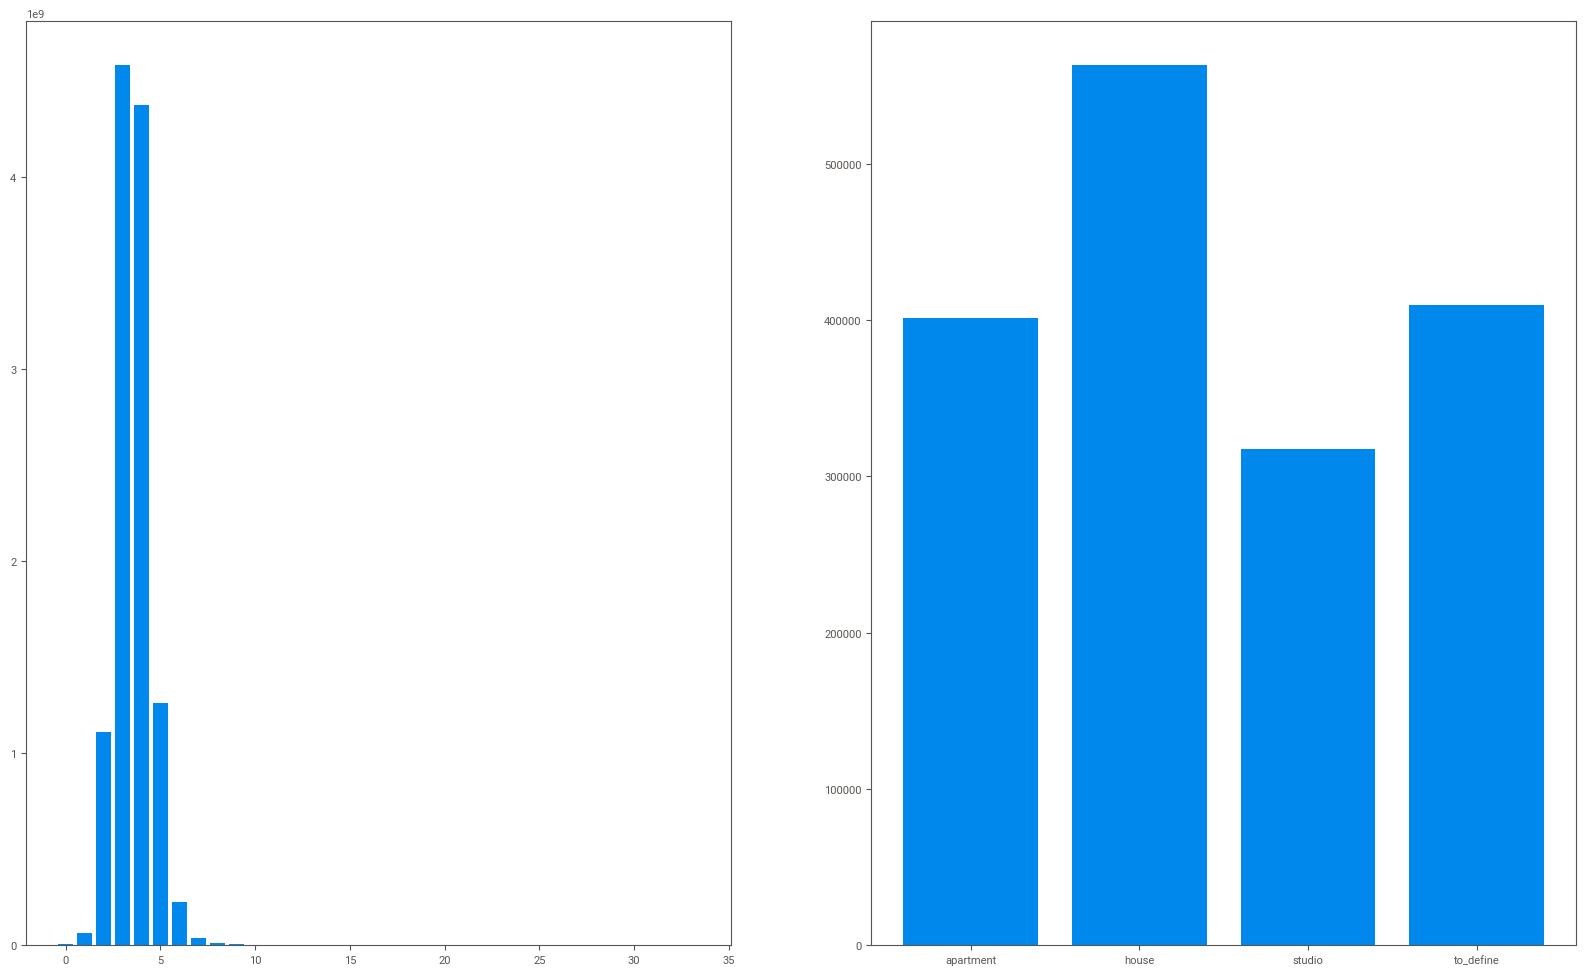

In [84]:

fig=plt.figure(figsize=(20,12))
specs= gridspec.GridSpec(ncols=2,nrows=2,figure=fig)
ax4=fig.add_subplot(specs[:,0])#first col
ax5=fig.add_subplot(specs[:,1]) #second row- first column

ax4.bar(by_bedrooms['bedrooms'],by_bedrooms['price'])
ax5.bar(by_dormitory_type['dormitory_type'],by_dormitory_type['price'])


### 59. Create a dashboard with the charts from questions 53 and 55  
(Dashboard layout: 2 rows)

<BarContainer object of 4 artists>

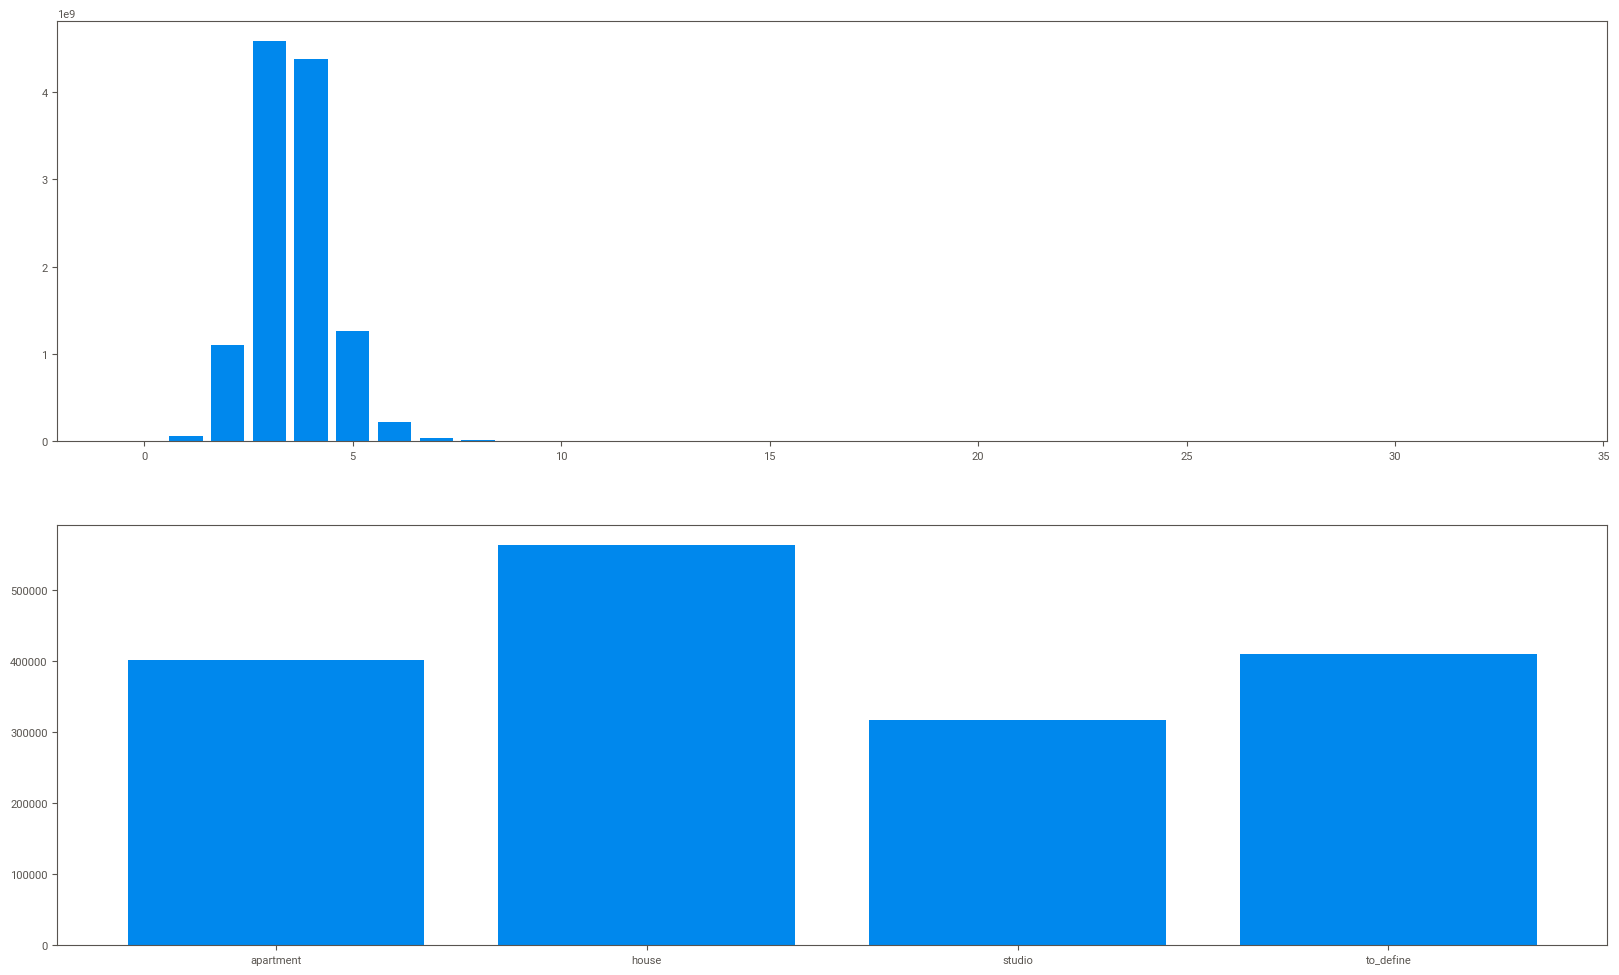

In [85]:
fig=plt.figure(figsize=(20,12))
specs= gridspec.GridSpec(ncols=2,nrows=2,figure=fig)
ax4=fig.add_subplot(specs[0,:])#first col
ax5=fig.add_subplot(specs[1,:]) #second row- first column

ax4.bar(by_bedrooms['bedrooms'],by_bedrooms['price'])
ax5.bar(by_dormitory_type['dormitory_type'],by_dormitory_type['price'])

### 60. Create a chart where the point size represents the living room size.

In [86]:
house= data[['id','lat','long','sqft_living']]

fig= px.scatter_map( house,
                      lat='lat',
                      lon='long',
                      size ='sqft_living',
                      color_continuous_scale=px.colors.cyclical.IceFire,
                      size_max=15,
                      zoom=10)
fig.update_layout(mapbox_style ='open-street-map')
fig.update_layout(height=600,margin={'r':0,'t':0,'l':0,'b':0})
fig.show()

### 61. What is the number of properties by level?

- Level 0: Price between R$ 0.00 and R$ 321,950  
- Level 1: Price between R$ 321,950 and R$ 450,000  
- Level 2: Price between R$ 450,000 and R$ 645,000  
- Level 3: Price above R$ 645,000  

Populate a new column called `level` based on the defined price ranges.

In [87]:
data.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'level', 'house_age', 'dormitory_type', 'condition_type',
       'year', 'day', 'year_week'],
      dtype='object')

In [88]:
#First option
data['property_level'] = 'NA'
data.loc[(data['price'] >= 0) & (data['price'] < 321950), 'property_level'] = 'property_level_0'
data.loc[(data['price'] >= 321950) & (data['price'] < 450000), 'property_level'] = 'property_level_1'
data.loc[(data['price'] >= 450000) & (data['price'] < 645000), 'property_level'] = 'property_level_2'
data.loc[(data['price'] >= 645000), 'property_level'] = 'property_level_3'
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,lat,long,level,house_age,dormitory_type,condition_type,year,day,year_week,property_level
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,47.51,-122.26,low_level,new_house,house,regular,2014,2014-10-13,2014-41,property_level_0
1,6414100192,2014-12-09,538000.00,3,2.25,2570,7242,2.00,0,0,...,47.72,-122.32,low_level,new_house,house,regular,2014,2014-12-09,2014-49,property_level_2
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,47.74,-122.23,low_level,new_house,apartment,regular,2015,2015-02-25,2015-08,property_level_0
3,2487200875,2014-12-09,604000.00,4,3.00,1960,5000,1.00,0,0,...,47.52,-122.39,high_level,new_house,house,good,2014,2014-12-09,2014-49,property_level_2
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,47.62,-122.05,low_level,new_house,house,regular,2015,2015-02-18,2015-07,property_level_2


In [89]:
#LOOP IF ELSE e FOR (Second option)
data['property_level'] = 'NA'
for i in range(len(data)):
    if (data.loc[i,'price'] > 0) & (data.loc[i,'price'] < 321950):
        data.loc[i,'property_level'] = 'property_level_0'
    elif (data.loc[i,'price'] > 321950) & (data.loc[i,'price'] < 450000):
        data.loc[i,'property_level'] = 'property_level_1'
    elif (data.loc[i,'price'] > 450000) & (data.loc[i,'price'] < 645000):
        data.loc[i,'property_level'] = 'property_level_2'    
    else:
        data.loc[i,'property_level'] = 'property_level_3'
data.head()        

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,lat,long,level,house_age,dormitory_type,condition_type,year,day,year_week,property_level
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,47.51,-122.26,low_level,new_house,house,regular,2014,2014-10-13,2014-41,property_level_0
1,6414100192,2014-12-09,538000.00,3,2.25,2570,7242,2.00,0,0,...,47.72,-122.32,low_level,new_house,house,regular,2014,2014-12-09,2014-49,property_level_2
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,47.74,-122.23,low_level,new_house,apartment,regular,2015,2015-02-25,2015-08,property_level_0
3,2487200875,2014-12-09,604000.00,4,3.00,1960,5000,1.00,0,0,...,47.52,-122.39,high_level,new_house,house,good,2014,2014-12-09,2014-49,property_level_2
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,47.62,-122.05,low_level,new_house,house,regular,2015,2015-02-18,2015-07,property_level_2


### 62. Add the following information to each property:

- Street name  
- House number  
- Neighborhood name  
- City name  
- State name  

In [90]:
#initialize Nominatim API
geolocator=Nominatim(user_agent='geoAPI')#pode ser dado qualquer nome

In [91]:
#Test API response
response=geolocator.reverse('47.5112,-122.257')
response.raw

{'place_id': 324510325,
 'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright',
 'osm_type': 'way',
 'osm_id': 236673596,
 'lat': '47.5112582',
 'lon': '-122.2573593',
 'class': 'building',
 'type': 'house',
 'place_rank': 30,
 'importance': 7.72983901731444e-05,
 'addresstype': 'building',
 'name': '',
 'display_name': '10011, 61st Avenue South, Rainier Beach, Seattle, King County, Washington, 98178, United States',
 'address': {'house_number': '10011',
  'road': '61st Avenue South',
  'neighbourhood': 'Rainier Beach',
  'city': 'Seattle',
  'county': 'King County',
  'state': 'Washington',
  'ISO3166-2-lvl4': 'US-WA',
  'postcode': '98178',
  'country': 'United States',
  'country_code': 'us'},
 'boundingbox': ['47.5112110', '47.5113089', '-122.2574505', '-122.2572671']}

In [92]:
'''
#Warning: Too long to execute (~6h)
#create empty rows
data['road'] ='NA'
data['house_number'] ='NA'
data['neighbourhood'] ='NA'
data['city'] ='NA'
data['county'] ='NA'
data['state'] ='NA'


geolocator=Nominatim(user_agent='geoapiAPI')
for i in range(len(data)):
    query = str(data.loc[i,'lat']) + ',' + str(data.loc[i,'long'])
    #API request
    #print('Loop:{}/{}'.format(i,len(data)))
    response=geolocator.reverse(query)
    #populate data
    #o if é caso tiver o dado populado, caso contrario passa. Se não tiver isso ao não encontrar um dado da erro
    if 'house_number' in response.raw['address']:
        data.loc[i,'house_number'] =response.raw['address']['house_number']
    if 'road' in response.raw['address']:    
        data.loc[i,'road']         =response.raw['address']['road']
    if 'neighbourhood' in response.raw['address']:       
        data.loc[i,'neighbourhood']=response.raw['address']['neighbourhood']
    if 'city' in response.raw['address']:      
        data.loc[i,'city']         =response.raw['address']['city']
    if 'county' in response.raw['address']:     
        data.loc[i,'county']       =response.raw['address']['county']
    if 'state' in response.raw['address']:
        data.loc[i,'state']        =response.raw['address']['state']
'''

"\n#Warning: Too long to execute (~6h)\n#create empty rows\ndata['road'] ='NA'\ndata['house_number'] ='NA'\ndata['neighbourhood'] ='NA'\ndata['city'] ='NA'\ndata['county'] ='NA'\ndata['state'] ='NA'\n\n\ngeolocator=Nominatim(user_agent='geoapiAPI')\nfor i in range(len(data)):\n    query = str(data.loc[i,'lat']) + ',' + str(data.loc[i,'long'])\n    #API request\n    #print('Loop:{}/{}'.format(i,len(data)))\n    response=geolocator.reverse(query)\n    #populate data\n    #o if é caso tiver o dado populado, caso contrario passa. Se não tiver isso ao não encontrar um dado da erro\n    if 'house_number' in response.raw['address']:\n        data.loc[i,'house_number'] =response.raw['address']['house_number']\n    if 'road' in response.raw['address']:    \n        data.loc[i,'road']         =response.raw['address']['road']\n    if 'neighbourhood' in response.raw['address']:       \n        data.loc[i,'neighbourhood']=response.raw['address']['neighbourhood']\n    if 'city' in response.raw['addr

In [93]:
'''
data.head()
report= data.copy()
# salving as .csv
report.to_csv('datasets/kc_house_data_address_updated.csv', index=False) #index false reseta o indice
'''

"\ndata.head()\nreport= data.copy()\n# salving as .csv\nreport.to_csv('datasets/kc_house_data_address_updated.csv', index=False) #index false reseta o indice\n"

### 63. Create an interactive dashboard to select a range of available property by date

In [94]:
#prepare dataset
data=pd.read_csv('datasets/kc_house_data.csv')

#change date format to string 
data['year'] =pd.to_datetime(data['date']).dt.strftime('%Y')
data['date'] =pd.to_datetime(data['date']).dt.strftime('%Y-%m-%d')
data['year_week'] =pd.to_datetime(data['date']).dt.strftime('%Y-%U')

#widgets to control data
date_limit = widgets.SelectionSlider(
    options=data['date'].sort_values().unique().tolist(),
    value = '2014-12-01',
    description='Available',
    continuous_update=False,
    orientation ='horizontal',
    readout=True)

def update_map (data,limit):
    #filter data
    df = data[data['date'] >=limit].copy()
    
    fig=plt.figure(figsize=(21,12))
    specs=gridspec.GridSpec(ncols=2,nrows=2,figure=fig)
    ax1 = fig.add_subplot(specs[0,:]) #first rows
    ax2 = fig.add_subplot(specs[1,0]) #second row First column
    ax3 = fig.add_subplot(specs[1,1]) #second row second column

    by_year = df[['id','year']].groupby('year').sum().reset_index()
    ax1.bar(by_year['year'],by_year['id'])
    
    by_day = df[['id','date']].groupby('date').mean().reset_index()
    ax2.plot(by_day['date'],by_day['id'])
    ax2.set_title('title: Avg Price by Day')
    
    by_week_of_year = df[['id','year_week']].groupby('year_week').mean().reset_index()
    ax3.bar(by_week_of_year['year_week'],by_week_of_year['id'])
    ax3.set_title('title: Avg Price by week of year')
    plt.xticks(rotation=60);


In [95]:
widgets.interactive(update_map,data=fixed(data),limit=date_limit)

interactive(children=(SelectionSlider(continuous_update=False, description='Available', index=212, options=('2…

# Insights

# *Business Questions*

## Which properties should House Rocket buy and at what price ?

#### Solution Planning
Goal: Identify the best investment opportunities for House Rocket.

Strategy: * Group properties by region (ZIP code).

Calculate the mean price for each specific region.

Action: I will suggest buying properties that are below the mean price and in good condition.

Columns: Property ID |	Region |	Property Price |	Median Price | Condition | Status

In [96]:
df1 = data[['price','zipcode']].groupby('zipcode').mean().reset_index()
df1 = df1.rename(columns={'price': 'mean_price'})
df1.head()
m1 = pd.merge( data, df1, on='zipcode', how='inner' )
m1.head()
#SInce the condition is 1-5. I will recomend only the properties in  starting from good state(3),


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,year_week,mean_price
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,1955,0,98178,47.51,-122.26,1340,5650,2014,2014-41,310612.76
1,6414100192,2014-12-09,538000.00,3,2.25,2570,7242,2.00,0,0,...,1951,1991,98125,47.72,-122.32,1690,7639,2014,2014-49,469455.77
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,1933,0,98028,47.74,-122.23,2720,8062,2015,2015-08,462480.04
3,2487200875,2014-12-09,604000.00,4,3.00,1960,5000,1.00,0,0,...,1965,0,98136,47.52,-122.39,1360,5000,2014,2014-49,551688.67
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,1987,0,98074,47.62,-122.05,1800,7503,2015,2015-07,685605.78


In [97]:
df2 = m1.loc[m1['condition'] >=3]
df2['Status'] = 'NA'
df2.head()
#will use apply instead of map, because map does not work with multiple columns
df2['Status']= df2.apply(lambda x: 'Buy' if x['price'] < x['mean_price'] else 'Not Buy', axis=1)
df2.head()

/tmp/ipykernel_7647/2670773812.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_7647/2670773812.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,year_week,mean_price,Status
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,0,98178,47.51,-122.26,1340,5650,2014,2014-41,310612.76,Buy
1,6414100192,2014-12-09,538000.00,3,2.25,2570,7242,2.00,0,0,...,1991,98125,47.72,-122.32,1690,7639,2014,2014-49,469455.77,Not Buy
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,0,98028,47.74,-122.23,2720,8062,2015,2015-08,462480.04,Buy
3,2487200875,2014-12-09,604000.00,4,3.00,1960,5000,1.00,0,0,...,0,98136,47.52,-122.39,1360,5000,2014,2014-49,551688.67,Not Buy
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,0,98074,47.62,-122.05,1800,7503,2015,2015-07,685605.78,Buy


## Once the property is purchased, when would be the best time to sell it?

### When it would be the best time to sell?
Refined Strategy: I will analyze price seasonality at the regional level.

Reasoning: Real estate trends are local; therefore, the "best month to sell" may vary depending on the property's ZIP code.

Calculation: I will compute the mean price grouped by zipcode and month to ensure the sales strategy is tailored to each specific market.

In [98]:
df3= df2.copy()
df3['month'] = pd.to_datetime(df3['date']).dt.month
df3.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,zipcode,lat,long,sqft_living15,sqft_lot15,year,year_week,mean_price,Status,month
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,98178,47.51,-122.26,1340,5650,2014,2014-41,310612.76,Buy,10
1,6414100192,2014-12-09,538000.00,3,2.25,2570,7242,2.00,0,0,...,98125,47.72,-122.32,1690,7639,2014,2014-49,469455.77,Not Buy,12
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,98028,47.74,-122.23,2720,8062,2015,2015-08,462480.04,Buy,2
3,2487200875,2014-12-09,604000.00,4,3.00,1960,5000,1.00,0,0,...,98136,47.52,-122.39,1360,5000,2014,2014-49,551688.67,Not Buy,12
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,98074,47.62,-122.05,1800,7503,2015,2015-07,685605.78,Buy,2


In [99]:
df4 = df3[['month','zipcode','price']].groupby(['zipcode','month']).mean().reset_index()
df4_monthly_mean=df4.rename(columns={'price':'monthly_mean_price'})
df4_monthly_mean.head()

,zipcode,month,monthly_mean_price
0,98001,1,278641.00
1,98001,2,296576.47
2,98001,3,268462.65
3,98001,4,329712.41
4,98001,5,253686.22


### **What a price to sell?**


* **Context:** Real estate prices fluctuate based on both location and time of year.
* **Strategy:** I compared the **Monthly Regional Mean** against the **Overall Regional Mean** to determine the markup.
* **Decision Rules:**
    1. If **Monthly Mean < Overall Regional Mean**: The market is in a "low" phase. I recommend a **30% markup** to maximize profit or account for the holding period.
    2. If **Monthly Mean >= Overall Regional Mean**: The market is in a "high" phase. I recommend a **10% markup** to ensure a quick sale while the market is favorable.

In [100]:
#Merging dataframes
df_final = pd.merge(df3, df4_monthly_mean, on=['zipcode', 'month'], how='inner')
df_final.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,lat,long,sqft_living15,sqft_lot15,year,year_week,mean_price,Status,month,monthly_mean_price
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,47.51,-122.26,1340,5650,2014,2014-41,310612.76,Buy,10,290297.41
1,6414100192,2014-12-09,538000.00,3,2.25,2570,7242,2.00,0,0,...,47.72,-122.32,1690,7639,2014,2014-49,469455.77,Not Buy,12,506628.12
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,47.74,-122.23,2720,8062,2015,2015-08,462480.04,Buy,2,423835.71
3,2487200875,2014-12-09,604000.00,4,3.00,1960,5000,1.00,0,0,...,47.52,-122.39,1360,5000,2014,2014-49,551688.67,Not Buy,12,515844.12
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,47.62,-122.05,1800,7503,2015,2015-07,685605.78,Buy,2,642096.67


In [101]:
#drop  registres with Status not buy values
df_final = df_final[df_final['Status']=='Buy']
df_final.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,lat,long,sqft_living15,sqft_lot15,year,year_week,mean_price,Status,month,monthly_mean_price
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,47.51,-122.26,1340,5650,2014,2014-41,310612.76,Buy,10,290297.41
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,47.74,-122.23,2720,8062,2015,2015-08,462480.04,Buy,2,423835.71
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,47.62,-122.05,1800,7503,2015,2015-07,685605.78,Buy,2,642096.67
6,1321400060,2014-06-27,257500.00,3,2.25,1715,6819,2.00,0,0,...,47.31,-122.33,2238,6819,2014,2014-25,294111.28,Buy,6,295044.74
7,2008000270,2015-01-15,291850.00,3,1.50,1060,9711,1.00,0,0,...,47.41,-122.31,1650,9711,2015,2015-02,302878.88,Buy,1,318146.88


In [102]:
df_final['Suggested_Price']= df_final.apply(lambda x: x['price']*1.30 if x['monthly_mean_price'] < x['mean_price'] else x['price']*1.10, axis=1)
df_final.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,long,sqft_living15,sqft_lot15,year,year_week,mean_price,Status,month,monthly_mean_price,Suggested_Price
0,7129300520,2014-10-13,221900.00,3,1.00,1180,5650,1.00,0,0,...,-122.26,1340,5650,2014,2014-41,310612.76,Buy,10,290297.41,288470.00
2,5631500400,2015-02-25,180000.00,2,1.00,770,10000,1.00,0,0,...,-122.23,2720,8062,2015,2015-08,462480.04,Buy,2,423835.71,234000.00
4,1954400510,2015-02-18,510000.00,3,2.00,1680,8080,1.00,0,0,...,-122.05,1800,7503,2015,2015-07,685605.78,Buy,2,642096.67,663000.00
6,1321400060,2014-06-27,257500.00,3,2.25,1715,6819,2.00,0,0,...,-122.33,2238,6819,2014,2014-25,294111.28,Buy,6,295044.74,283250.00
7,2008000270,2015-01-15,291850.00,3,1.50,1060,9711,1.00,0,0,...,-122.31,1650,9711,2015,2015-02,302878.88,Buy,1,318146.88,321035.00


### Calculation of profit

In [103]:
df_final['Profit']= df_final.apply(lambda x: x['Suggested_Price'] - x['price'], axis=1)
df_final.head()
print('The Total amount of expected profit is {:.2f}'.format(df_final['Profit'].sum()))


The Total amount of expected profit is 1121790262.50


In [104]:
#Top 30 most profitable houses
df_top30= df_final.sort_values('Profit', ascending=False).head(30)
df_top30[['id','price','Suggested_Price','Profit']] 

,id,price,Suggested_Price,Profit
19154,2525049113,1950000.00,2535000.00,585000.00
14109,2425049107,1950000.00,2535000.00,585000.00
18719,2425049066,1920000.00,2496000.00,576000.00
3727,2540700110,1905000.00,2476500.00,571500.00
5531,6447300225,1880000.00,2444000.00,564000.00
21312,3262300818,1865000.00,2424500.00,559500.00
12174,3738000070,1712750.00,2226575.00,513825.00
13097,3262300322,1651000.00,2146300.00,495300.00
6799,3262300235,1555000.00,2021500.00,466500.00
18699,5427100150,1410000.00,1833000.00,423000.00


# Machine Learning

## Descricao dos dados

### 1.1 Objetivo do projeto

O objetivo desta etapa e realizar a validacao inicial da base de dados de imoveis (House Rocket) para o desenvolvimento de modelos de Machine Learning focados na previsao de precos de imoveis (`price`).

### 1.2 Visão geral da base

Carregamento da base de dados, verificacao do tamanho (shape) e exibicao das cinco primeiras linhas.

In [105]:
# Carregamento da base de dados
data = pd.read_csv('./datasets/kc_house_data.csv')

# Tamanho do dataframe (linhas, colunas)
print("Tamanho do dataframe:", data.shape)

# Visualizacao das cinco primeiras linhas do dataframe
display(data.head())

Tamanho do dataframe: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.00,3,1.00,1180,5650,1.00,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,538000.00,3,2.25,2570,7242,2.00,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,180000.00,2,1.00,770,10000,1.00,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,604000.00,4,3.00,1960,5000,1.00,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,510000.00,3,2.00,1680,8080,1.00,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


### 1.3 Dicionário resumido das variáveis

Listagem dos atributos presentes no conjunto de dados e seus respectivos tipos de dados.

In [106]:
# Lista de colunas e seus tipos de dados
print("Tipos de dados por coluna:")
print(data.dtypes)

Tipos de dados por coluna:
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


### 1.4 Qualidade dos dados

Verificacao da existencia de valores nulos (ausentes) e contagem de registros duplicados.

In [107]:
# Identificacao de colunas com valores nulos/ausentes
nulos_por_coluna = data.isnull().sum()
colunas_com_nulos = nulos_por_coluna[nulos_por_coluna > 0]

print("Valores nulos por coluna:")
if colunas_com_nulos.empty:
    print("Nenhuma coluna possui valores ausentes.")
else:
    print(colunas_com_nulos)

# Quantidade total de linhas duplicadas
linhas_duplicadas = data.duplicated().sum()
print("\nQuantidade de linhas duplicadas:", linhas_duplicadas)

Valores nulos por coluna:
Nenhuma coluna possui valores ausentes.

Quantidade de linhas duplicadas: 0


### 1.5 Análise da variável-alvo

Analise descritiva da coluna `price`, que representa a variavel-alvo a ser prevista.

In [108]:
# Estatisticas descritivas da variavel-alvo 'price'
print("Estatisticas descritivas da coluna 'price':")
print(data['price'].describe())

Estatisticas descritivas da coluna 'price':
count     21613.00
mean     540088.14
std      367127.20
min       75000.00
25%      321950.00
50%      450000.00
75%      645000.00
max     7700000.00
Name: price, dtype: float64


### 1.6 Principais conclusões

A validacao rapida permitiu mapear a estrutura inicial da base de dados, a consistencia dos tipos de variaveis e a presenca de possiveis valores ausentes ou duplicidades. Com esse diagnostico inicial realizado sem alterar o conjunto original, a base esta pronta para seguir para as etapas de **feature engineering** e **preparacao dos dados**, onde serao realizados os tratamentos necessarios (ajuste de tipos, tratamento de duplicadas/nulos se houver), a criacao de novas variaveis descritivas e a adequacao dos dados para a modelagem estatistica e de Machine Learning.

# 2. Feature Engineering

## 2.1 Criação da base para Machine Learning

In [109]:
# Criacao da copia exclusiva para Machine Learning sem alterar o dataframe original 'data'
if 'data' in globals():
    df_ml = data.copy()
    print("Copia do dataframe criada com sucesso em 'df_ml'.")
    print("Tamanho de df_ml (linhas, colunas):", df_ml.shape)
    display(df_ml.head())
else:
    print("Aviso: Dataframe 'data' nao encontrado no ambiente.")

Copia do dataframe criada com sucesso em 'df_ml'.
Tamanho de df_ml (linhas, colunas): (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.00,3,1.00,1180,5650,1.00,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,538000.00,3,2.25,2570,7242,2.00,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,180000.00,2,1.00,770,10000,1.00,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,604000.00,4,3.00,1960,5000,1.00,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,510000.00,3,2.00,1680,8080,1.00,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


## 2.2 Variáveis temporais da venda

In [110]:
# Validacao da existencia da coluna 'date'
if 'date' in df_ml.columns:
    # Conversao de date para datetime
    date_dt = pd.to_datetime(df_ml['date'], errors='coerce')
    
    # Criacao de variaveis temporais para capturar possivel sazonalidade de preco
    df_ml['sale_year'] = date_dt.dt.year
    df_ml['sale_month'] = date_dt.dt.month
    df_ml['sale_quarter'] = date_dt.dt.quarter
    
    # Exibicao das colunas temporais (date mantida apenas para auditoria temporaria)
    cols_display_22 = [c for c in ['date', 'sale_year', 'sale_month', 'sale_quarter'] if c in df_ml.columns]
    display(df_ml[cols_display_22].head())
else:
    print("Aviso: Coluna 'date' nao encontrada em df_ml.")

,date,sale_year,sale_month,sale_quarter
0,20141013T000000,2014,10,4
1,20141209T000000,2014,12,4
2,20150225T000000,2015,2,1
3,20141209T000000,2014,12,4
4,20150218T000000,2015,2,1


## 2.3 Variáveis de idade e reforma

In [111]:
# Identificacao flexivel das colunas de ano de construcao e reforma
col_built = 'yr_built' if 'yr_built' in df_ml.columns else ('yrbuilt' if 'yrbuilt' in df_ml.columns else None)
col_renovated = 'yr_renovated' if 'yr_renovated' in df_ml.columns else ('yrrenovated' if 'yrrenovated' in df_ml.columns else None)

if col_built and col_renovated and 'sale_year' in df_ml.columns:
    # Conversao numerica de ano de construcao
    if pd.api.types.is_datetime64_any_dtype(df_ml[col_built]):
        yr_built_num = pd.to_datetime(df_ml[col_built], errors='coerce').dt.year
    else:
        yr_built_num = pd.to_numeric(df_ml[col_built], errors='coerce')
        
    # Conversao numerica de ano de reforma (tratar 0 como ausencia de reforma)
    if pd.api.types.is_datetime64_any_dtype(df_ml[col_renovated]):
        yr_renovated_num = pd.to_datetime(df_ml[col_renovated], errors='coerce').dt.year
    else:
        yr_renovated_num = pd.to_numeric(df_ml[col_renovated], errors='coerce')

    # Criacao da idade do imovel no momento da venda
    df_ml['property_age'] = df_ml['sale_year'] - yr_built_num
    # Substituicao de valores negativos por NaN
    df_ml.loc[df_ml['property_age'] < 0, 'property_age'] = np.nan

    # Indicador se o imovel foi reformado (1 para ano valido > 0, senao 0)
    df_ml['was_renovated'] = np.where((yr_renovated_num.notnull()) & (yr_renovated_num > 0), 1, 0)

    # Tempo desde a ultima reforma (apenas para imoveis reformados; senao NaN)
    df_ml['years_since_renovation'] = np.where(
        df_ml['was_renovated'] == 1,
        df_ml['sale_year'] - yr_renovated_num,
        np.nan
    )
    # Substituicao de valores negativos por NaN
    df_ml.loc[df_ml['years_since_renovation'] < 0, 'years_since_renovation'] = np.nan

    # Exibicao das colunas de idade e reforma
    cols_display_23 = ['sale_year', col_built, col_renovated, 'property_age', 'was_renovated', 'years_since_renovation']
    display(df_ml[cols_display_23].head())
else:
    print("Aviso: Uma ou mais colunas necessarias ('yr_built'/'yrbuilt', 'yr_renovated'/'yrrenovated', 'sale_year') nao foram encontradas.")

,sale_year,yr_built,yr_renovated,property_age,was_renovated,years_since_renovation
0,2014,1955,0,59.00,0,NaN
1,2014,1951,1991,63.00,1,23.00
2,2015,1933,0,82.00,0,NaN
3,2014,1965,0,49.00,0,NaN
4,2015,1987,0,28.00,0,NaN


## 2.4 Variáveis de estrutura e proporções

In [112]:
# Identificacao flexivel das colunas de estrutura
col_basement = 'sqft_basement' if 'sqft_basement' in df_ml.columns else ('sqftbasement' if 'sqftbasement' in df_ml.columns else None)
col_living = 'sqft_living' if 'sqft_living' in df_ml.columns else ('sqftliving' if 'sqftliving' in df_ml.columns else None)
col_lot = 'sqft_lot' if 'sqft_lot' in df_ml.columns else ('sqftlot' if 'sqftlot' in df_ml.columns else None)
col_bed = 'bedrooms' if 'bedrooms' in df_ml.columns else None
col_bath = 'bathrooms' if 'bathrooms' in df_ml.columns else None

req_cols_24 = [col_basement, col_living, col_lot, col_bed, col_bath]

if all(c is not None for c in req_cols_24):
    # Indicador de presenca de porao (1 se sqft_basement > 0, senao 0)
    df_ml['has_basement'] = np.where(df_ml[col_basement] > 0, 1, 0)

    # Area total do imovel (soma da area habitavel e do lote)
    df_ml['total_area'] = df_ml[col_living] + df_ml[col_lot]

    # Razao entre area habitavel e area do lote (trocar zero do lote por NaN para evitar infinito)
    sqft_lot_safe = df_ml[col_lot].replace(0, np.nan)
    df_ml['living_to_lot_ratio'] = df_ml[col_living] / sqft_lot_safe

    # Proporcao de banheiros por quarto (trocar zero de quartos por NaN para evitar infinito)
    bedrooms_safe = df_ml[col_bed].replace(0, np.nan)
    df_ml['bathrooms_per_bedroom'] = df_ml[col_bath] / bedrooms_safe

    # Substituicao de valores infinitos por NaN nas novas variaveis
    for col in ['living_to_lot_ratio', 'bathrooms_per_bedroom']:
        df_ml[col] = df_ml[col].replace([np.inf, -np.inf], np.nan)

    # Exibicao das colunas estruturais e de proporcao
    cols_display_24 = [col_living, col_lot, col_bed, col_bath, 'has_basement', 'total_area', 'living_to_lot_ratio', 'bathrooms_per_bedroom']
    display(df_ml[cols_display_24].head())
else:
    print("Aviso: Uma ou mais colunas necessarias para estrutura/proporcoes nao foram encontradas.")

,sqft_living,sqft_lot,bedrooms,bathrooms,has_basement,total_area,living_to_lot_ratio,bathrooms_per_bedroom
0,1180,5650,3,1.00,0,6830,0.21,0.33
1,2570,7242,3,2.25,1,9812,0.35,0.75
2,770,10000,2,1.00,0,10770,0.08,0.50
3,1960,5000,4,3.00,1,6960,0.39,0.75
4,1680,8080,3,2.00,0,9760,0.21,0.67


## 2.5 Prevenção de data leakage e validação final

In [113]:
# Lista de colunas com potencial de data leakage
leakage_columns = [
    'level',
    'propertylevel',
    'meanprice',
    'monthlymeanprice',
    'Status',
    'SuggestedPrice'
]

# Remocao apenas das colunas da lista que realmente existem em df_ml
cols_to_remove = [col for col in leakage_columns if col in df_ml.columns]
if cols_to_remove:
    df_ml.drop(columns=cols_to_remove, inplace=True)
    print("Colunas de data leakage removidas:", cols_to_remove)
else:
    print("Nenhuma coluna da lista de data leakage foi encontrada para remocao.")

# Dimensao final de df_ml
print("Dimensao final de df_ml (linhas, colunas):", df_ml.shape)

# Tabela com as novas features criadas e contagem de valores ausentes
new_features = [
    'sale_year', 'sale_month', 'sale_quarter',
    'property_age', 'was_renovated', 'years_since_renovation',
    'has_basement', 'total_area', 'living_to_lot_ratio', 'bathrooms_per_bedroom'
]
existing_new_features = [f for f in new_features if f in df_ml.columns]
null_summary = df_ml[existing_new_features].isnull().sum().to_frame(name='valores_ausentes')
print("\nContagem de valores ausentes nas novas features:")
display(null_summary)

# Validacao de valores infinitos nas colunas numericas
num_cols = df_ml.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df_ml[num_cols]).sum().sum()
print("\nQuantidade total de valores infinitos nas colunas numericas:", inf_counts)

# Visualizacao final das 5 primeiras linhas
display(df_ml.head())

Nenhuma coluna da lista de data leakage foi encontrada para remocao.
Dimensao final de df_ml (linhas, colunas): (21613, 31)

Contagem de valores ausentes nas novas features:


,valores_ausentes
sale_year,0
sale_month,0
sale_quarter,0
property_age,12
was_renovated,0
years_since_renovation,20705
has_basement,0
total_area,0
living_to_lot_ratio,0
bathrooms_per_bedroom,13



Quantidade total de valores infinitos nas colunas numericas: 0


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sale_year,sale_month,sale_quarter,property_age,was_renovated,years_since_renovation,has_basement,total_area,living_to_lot_ratio,bathrooms_per_bedroom
0,7129300520,20141013T000000,221900.00,3,1.00,1180,5650,1.00,0,0,...,2014,10,4,59.00,0,NaN,0,6830,0.21,0.33
1,6414100192,20141209T000000,538000.00,3,2.25,2570,7242,2.00,0,0,...,2014,12,4,63.00,1,23.00,1,9812,0.35,0.75
2,5631500400,20150225T000000,180000.00,2,1.00,770,10000,1.00,0,0,...,2015,2,1,82.00,0,NaN,0,10770,0.08,0.50
3,2487200875,20141209T000000,604000.00,4,3.00,1960,5000,1.00,0,0,...,2014,12,4,49.00,0,NaN,1,6960,0.39,0.75
4,1954400510,20150218T000000,510000.00,3,2.00,1680,8080,1.00,0,0,...,2015,2,1,28.00,0,NaN,0,9760,0.21,0.67


### Resumo do Feature Engineering e Próximos Passos

- **Natureza das novas variáveis**: Foram criadas variáveis temporais (`sale_year`, `sale_month`, `sale_quarter`), de idade e reforma (`property_age`, `was_renovated`, `years_since_renovation`), além de métricas estruturais e proporções (`has_basement`, `total_area`, `living_to_lot_ratio`, `bathrooms_per_bedroom`).
- **Preservação da variável-alvo**: A variável `price` foi mantida intacta como a variável-alvo (target) da regressão.
- **Prevenção de Data Leakage**: Variáveis derivadas de preço ou de regras de negócio futuras foram checadas e removidas para garantir o rigor preditivo do modelo.
- **Próximas etapas**: A imputação de valores ausentes, o encoding de variáveis categóricas, o escalonamento de atributos e a seleção final de preditores serão realizados nas etapas posteriores.

# 3. Filtragem de Variáveis

## 3.1 Criação da base de seleção

In [114]:
# Criacao do dataframe df_selected a partir de df_ml (filtragem realizada apenas na copia)
if 'df_ml' in globals():
    df_selected = df_ml.copy()
    print("Copia do dataframe df_ml criada com sucesso em 'df_selected'.")
    print("Dimensao de df_selected (linhas, colunas):", df_selected.shape)
    print("\nLista de colunas disponiveis em df_selected:")
    print(list(df_selected.columns))
else:
    print("Aviso: Dataframe 'df_ml' nao encontrado no ambiente.")

Copia do dataframe df_ml criada com sucesso em 'df_selected'.
Dimensao de df_selected (linhas, colunas): (21613, 31)

Lista de colunas disponiveis em df_selected:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'sale_quarter', 'property_age', 'was_renovated', 'years_since_renovation', 'has_basement', 'total_area', 'living_to_lot_ratio', 'bathrooms_per_bedroom']


## 3.2 Exclusão de variáveis não elegíveis

In [115]:
# Lista de variaveis candidatas a exclusao com justificativas:
# - id: apenas identificador tecnico
# - date: transformada em variaveis temporais (sale_year, sale_month, sale_quarter)
# - yrbuilt, yrrenovated: representadas por property_age, was_renovated e years_since_renovation
# - level, propertylevel, meanprice, monthlymeanprice, Status, SuggestedPrice: potencial data leakage (criadas a partir de price)
# - sqftliving15, sqftlot15, total_area: exclusao para reduzir redundancia e manter o projeto simples
candidates_to_remove = [
    'id',
    'date',
    'yr_built', 'yrbuilt',
    'yr_renovated', 'yrrenovated',
    'level', 'propertylevel', 'meanprice', 'monthlymeanprice', 'Status', 'SuggestedPrice',
    'sqft_living15', 'sqftliving15',
    'sqft_lot15', 'sqftlot15',
    'total_area'
]

# Remocao de df_selected apenas das colunas que realmente existirem
removed_columns = [col for col in candidates_to_remove if col in df_selected.columns]

if removed_columns:
    df_selected.drop(columns=removed_columns, inplace=True)
    print("Lista das colunas efetivamente removidas:")
    print(removed_columns)
else:
    print("Nenhuma das colunas candidatas a exclusao foi encontrada em df_selected.")

# Dimensao de df_selected apos exclusao
print("\nDimensao de df_selected apos exclusao (linhas, colunas):", df_selected.shape)

Lista das colunas efetivamente removidas:
['id', 'date', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15', 'total_area']

Dimensao de df_selected apos exclusao (linhas, colunas): (21613, 24)


## 3.3 Análise de correlação

Correlacao de cada atributo numerico com 'price' (ordenada por valor absoluto):
sqft_living               0.70
grade                     0.67
sqft_above                0.61
bathrooms                 0.53
view                      0.40
sqft_basement             0.32
bedrooms                  0.31
lat                       0.31
bathrooms_per_bedroom     0.28
waterfront                0.27
floors                    0.26
has_basement              0.18
years_since_renovation   -0.13
was_renovated             0.13
living_to_lot_ratio       0.12
sqft_lot                  0.09
property_age             -0.05
zipcode                  -0.05
condition                 0.04
long                      0.02
sale_month               -0.01
sale_quarter             -0.01
sale_year                 0.00
Name: price, dtype: float64

Tabela de pares de preditores com correlacao absoluta >= 0.85:


,Variavel_1,Variavel_2,Correlacao
0,sqft_living,sqft_above,0.88
1,sale_month,sale_quarter,0.97


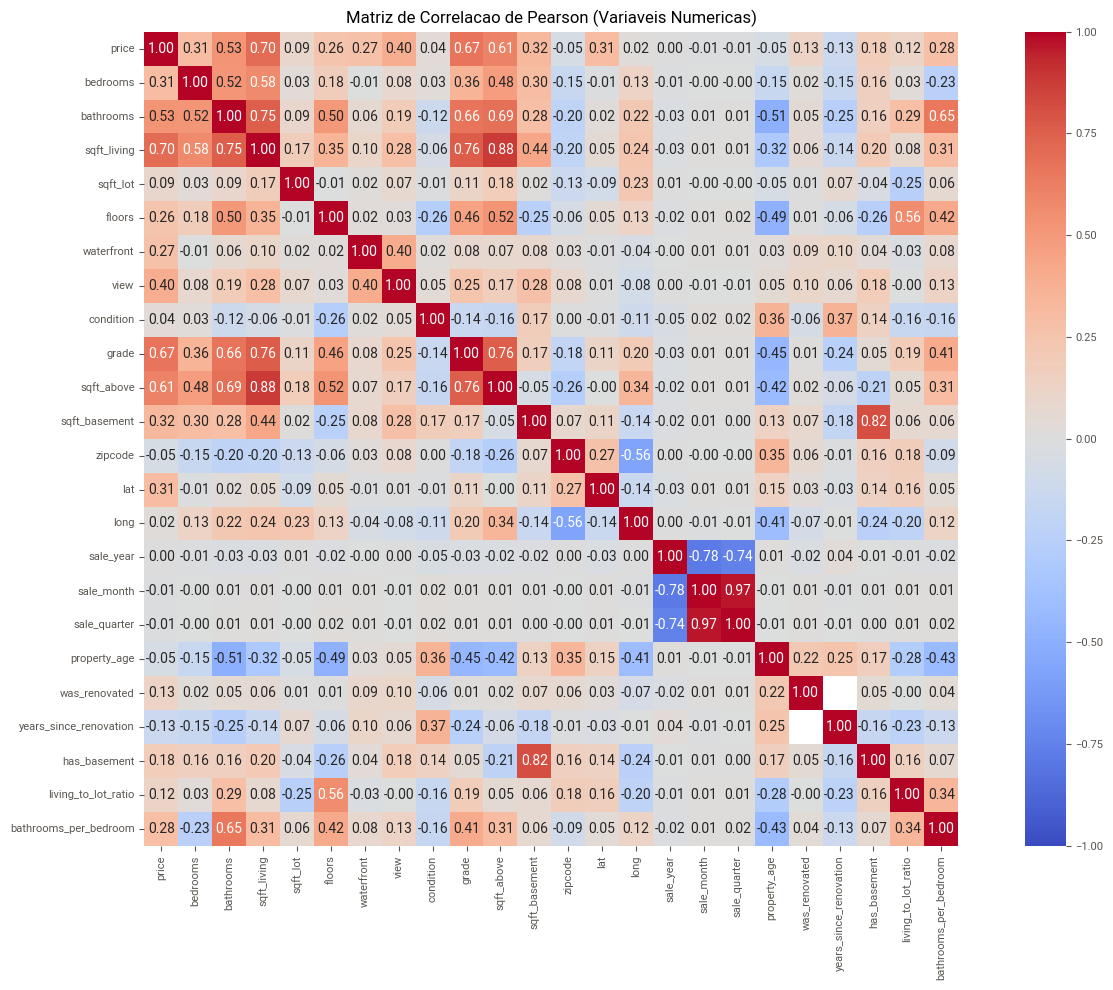

In [116]:
# Selecao apenas das variaveis numericas de df_selected
num_df = df_selected.select_dtypes(include=[np.number])

if not num_df.empty:
    # Calculo da matriz de correlacao de Pearson
    corr_matrix = num_df.corr(method='pearson')
    
    # Correlacao de cada atributo numerico com price (ordenada do maior para o menor valor absoluto)
    if 'price' in corr_matrix.columns:
        price_corr = corr_matrix['price'].drop('price')
        price_corr_sorted = price_corr.reindex(price_corr.abs().sort_values(ascending=False).index)
        print("Correlacao de cada atributo numerico com 'price' (ordenada por valor absoluto):")
        print(price_corr_sorted)
    
    # Identificacao de pares de variaveis preditoras com correlacao absoluta >= 0.85 (excluindo price)
    high_corr_pairs = []
    pred_cols = [c for c in num_df.columns if c != 'price']
    
    for i in range(len(pred_cols)):
        for j in range(i + 1, len(pred_cols)):
            col1 = pred_cols[i]
            col2 = pred_cols[j]
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) >= 0.85:
                high_corr_pairs.append({'Variavel_1': col1, 'Variavel_2': col2, 'Correlacao': corr_val})
                
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("\nTabela de pares de preditores com correlacao absoluta >= 0.85:")
    if not high_corr_df.empty:
        display(high_corr_df)
    else:
        print("Nenhum par de variaveis preditoras apresentou correlacao absoluta >= 0.85.")
        
    # Heatmap simples e legivel da matriz de correlacao
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
    plt.title("Matriz de Correlacao de Pearson (Variaveis Numericas)")
    plt.tight_layout()
    plt.show()
else:
    print("Aviso: Nenhuma variavel numerica encontrada em df_selected.")

## 3.4 Definição da base final

In [117]:
# Lista de preditores prioritarios conhecidos antes da venda
candidate_features = [
    'bedrooms',
    'bathrooms',
    'sqft_living', 'sqftliving',
    'sqft_lot', 'sqftlot',
    'floors',
    'waterfront',
    'view',
    'condition',
    'grade',
    'sqft_above', 'sqftabove',
    'sqft_basement', 'sqftbasement',
    'zipcode',
    'lat',
    'long',
    'sale_year',
    'sale_month',
    'sale_quarter',
    'property_age',
    'was_renovated',
    'years_since_renovation',
    'has_basement',
    'living_to_lot_ratio',
    'bathrooms_per_bedroom',
    'conditiontype',
    'dormitorytype',
    'houseage'
]

# Filtragem de selected_features para manter apenas colunas disponiveis em df_selected (sem price)
selected_features = [f for f in candidate_features if f in df_selected.columns and f != 'price']

# Identificacao de candidatas nao encontradas no dataframe
existing_base_names = [c.replace('_', '') for c in df_selected.columns]
not_found_features = [f for f in candidate_features if f not in df_selected.columns and f.replace('_', '') not in existing_base_names]

print("Variaveis selecionadas (selected_features):")
print(selected_features)

print("\nVariaveis candidatas nao encontradas:")
print(not_found_features if not_found_features else "Todas as principais variaveis candidatas foram encontradas.")

# Criacao do dataframe final df_model com as features selecionadas e price
if 'price' in df_selected.columns:
    df_model = df_selected[selected_features + ['price']].copy()
    print("\nDataFrame final 'df_model' criado com sucesso.")
    print("Dimensao final de df_model (linhas, colunas):", df_model.shape)
    display(df_model.head())
else:
    print("Erro: A coluna 'price' nao foi encontrada em df_selected.")

Variaveis selecionadas (selected_features):
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'zipcode', 'lat', 'long', 'sale_year', 'sale_month', 'sale_quarter', 'property_age', 'was_renovated', 'years_since_renovation', 'has_basement', 'living_to_lot_ratio', 'bathrooms_per_bedroom']

Variaveis candidatas nao encontradas:
['conditiontype', 'dormitorytype', 'houseage']

DataFrame final 'df_model' criado com sucesso.
Dimensao final de df_model (linhas, colunas): (21613, 24)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,sale_year,sale_month,sale_quarter,property_age,was_renovated,years_since_renovation,has_basement,living_to_lot_ratio,bathrooms_per_bedroom,price
0,3,1.00,1180,5650,1.00,0,0,3,7,1180,...,2014,10,4,59.00,0,NaN,0,0.21,0.33,221900.00
1,3,2.25,2570,7242,2.00,0,0,3,7,2170,...,2014,12,4,63.00,1,23.00,1,0.35,0.75,538000.00
2,2,1.00,770,10000,1.00,0,0,3,6,770,...,2015,2,1,82.00,0,NaN,0,0.08,0.50,180000.00
3,4,3.00,1960,5000,1.00,0,0,5,7,1050,...,2014,12,4,49.00,0,NaN,1,0.39,0.75,604000.00
4,3,2.00,1680,8080,1.00,0,0,3,8,1680,...,2015,2,1,28.00,0,NaN,0,0.21,0.67,510000.00


## 3.5 Validação final

In [118]:
# 1. Confirmar existencia de price em df_model
print("1. 'price' esta em df_model:", 'price' in df_model.columns)

# 2. Confirmar que price nao esta em selected_features
print("2. 'price' nao esta em selected_features:", 'price' not in selected_features)

# 3. Verificar se alguma variavel de data leakage permaneceu na base
leakage_list = ['level', 'propertylevel', 'meanprice', 'monthlymeanprice', 'Status', 'SuggestedPrice']
remaining_leakage = [c for c in leakage_list if c in df_model.columns]
print("3. Variaveis de data leakage remanescentes em df_model:", remaining_leakage if remaining_leakage else "Nenhuma (Validacao OK)")

# 4. Tipos de dados das colunas de df_model
print("\n4. Tipos de dados de df_model:")
print(df_model.dtypes)

# 5. Valores ausentes por coluna em df_model (sem tratar)
print("\n5. Valores ausentes por coluna em df_model:")
print(df_model.isnull().sum())

# 6. Quantidade de linhas duplicadas (sem remover)
print("\n6. Quantidade de linhas duplicadas em df_model:", df_model.duplicated().sum())

# 7. Quantidade de variaveis numericas e categoricas
num_vars = df_model.select_dtypes(include=[np.number]).columns.tolist()
cat_vars = df_model.select_dtypes(exclude=[np.number]).columns.tolist()
num_predictors = [v for v in num_vars if v != 'price']

print(f"\n7. Quantidade de preditores numericos: {len(num_predictors)}")
print(f"   Quantidade de preditores categoricos: {len(cat_vars)}")

# Mensagem final de confirmacao
print("\ndf_model esta pronto para a etapa de Preparacao dos Dados.")

1. 'price' esta em df_model: True
2. 'price' nao esta em selected_features: True
3. Variaveis de data leakage remanescentes em df_model: Nenhuma (Validacao OK)

4. Tipos de dados de df_model:
bedrooms                    int64
bathrooms                 float64
sqft_living                 int64
sqft_lot                    int64
floors                    float64
waterfront                  int64
view                        int64
condition                   int64
grade                       int64
sqft_above                  int64
sqft_basement               int64
zipcode                     int64
lat                       float64
long                      float64
sale_year                   int32
sale_month                  int32
sale_quarter                int32
property_age              float64
was_renovated               int64
years_since_renovation    float64
has_basement                int64
living_to_lot_ratio       float64
bathrooms_per_bedroom     float64
price                     

### Conclusão

- **Manutenção da variável-alvo**: A coluna `price` foi mantida intacta como a variável-alvo do modelo de regressão.
- **Exclusão de atributos não elegíveis**: Identificadores técnicos (`id`), data bruta (`date`), atributos redundantes definidos para simplificação do projeto (`sqft_living15`, `sqft_lot15`, `total_area`) e variáveis com potencial de data leakage (`level`, `propertylevel`, `meanprice`, `monthlymeanprice`, `Status`, `SuggestedPrice`) foram excluídos da base de seleção.
- **Preservação de atributos relevantes**: Foram preservadas características físicas, localização geográfica, condição do imóvel, idade, histórico de reforma e sazonalidade para a próxima etapa.
- **Status dos dados**: O conjunto de dados final `df_model` ainda não passou por imputação de valores ausentes, encoding de variáveis categóricas, escalonamento ou divisão entre treino e teste, estando pronto para a seção de Preparação dos Dados.

# 4. Preparação dos Dados

## 4.1 Criação das variáveis X e y

In [119]:
# Validacao da existencia da coluna 'price' em df_model
if 'price' in df_model.columns:
    # Criacao da matriz de atributos X sem a coluna price
    X = df_model.drop(columns=['price']).copy()
    
    # Criacao do vetor alvo y com a coluna price
    y = df_model['price'].copy()
    
    # Exibicao das dimensoes de X e y
    print("Dimensao de X (matriz de atributos):", X.shape)
    print("Dimensao de y (vetor alvo):", y.shape)
    
    # Exibicao das primeiras 5 linhas de X
    print("\nPrimeiras 5 linhas de X:")
    display(X.head())
    
    # Exibicao das primeiras 5 observacoes de y
    print("\nPrimeiras 5 observacoes de y:")
    display(y.head())
    
    # Mensagem de confirmacao da ausencia de price em X
    print("\nConfirmacao: A coluna 'price' nao esta presente na matriz de atributos X.")
else:
    print("Erro: A coluna 'price' nao foi encontrada no dataframe df_model.")

Dimensao de X (matriz de atributos): (21613, 23)
Dimensao de y (vetor alvo): (21613,)

Primeiras 5 linhas de X:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,long,sale_year,sale_month,sale_quarter,property_age,was_renovated,years_since_renovation,has_basement,living_to_lot_ratio,bathrooms_per_bedroom
0,3,1.00,1180,5650,1.00,0,0,3,7,1180,...,-122.26,2014,10,4,59.00,0,NaN,0,0.21,0.33
1,3,2.25,2570,7242,2.00,0,0,3,7,2170,...,-122.32,2014,12,4,63.00,1,23.00,1,0.35,0.75
2,2,1.00,770,10000,1.00,0,0,3,6,770,...,-122.23,2015,2,1,82.00,0,NaN,0,0.08,0.50
3,4,3.00,1960,5000,1.00,0,0,5,7,1050,...,-122.39,2014,12,4,49.00,0,NaN,1,0.39,0.75
4,3,2.00,1680,8080,1.00,0,0,3,8,1680,...,-122.05,2015,2,1,28.00,0,NaN,0,0.21,0.67



Primeiras 5 observacoes de y:


0   221900.00
1   538000.00
2   180000.00
3   604000.00
4   510000.00
Name: price, dtype: float64


Confirmacao: A coluna 'price' nao esta presente na matriz de atributos X.


## 4.2 Separação entre treino e teste

In [120]:
from sklearn.model_selection import train_test_split

# Divisao em conjuntos de treino (80%) e teste (20%) com seed aleatoria 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Exibicao das dimensoes dos quatro objetos
print("Dimensao de X_train:", X_train.shape)
print("Dimensao de X_test:", X_test.shape)
print("Dimensao de y_train:", y_train.shape)
print("Dimensao de y_test:", y_test.shape)

# Calculo e exibicao das proporcoes aproximadas
total_samples = len(X)
prop_train = (len(X_train) / total_samples) * 100
prop_test = (len(X_test) / total_samples) * 100

print(f"\nProporcao aproximada de treino: {prop_train:.2f}% ({len(X_train)} registros)")
print(f"Proporcao aproximada de teste:  {prop_test:.2f}% ({len(X_test)} registros)")

Dimensao de X_train: (17290, 23)
Dimensao de X_test: (4323, 23)
Dimensao de y_train: (17290,)
Dimensao de y_test: (4323,)

Proporcao aproximada de treino: 80.00% (17290 registros)
Proporcao aproximada de teste:  20.00% (4323 registros)


## 4.3 Identificação de variáveis numéricas e categóricas

In [121]:
import numpy as np

# Identificacao de colunas numericas e categoricas exclusivamente a partir de X_train
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Exibicao das listas e suas quantidades
print(f"Variaveis numericas ({len(numeric_features)}):")
print(numeric_features)

print(f"\nVariaveis categoricas ({len(categorical_features)}):")
print(categorical_features if categorical_features else "Nenhuma variavel categorica identificada em X_train.")

# Exibicao de valores ausentes por tipo em X_train
print("\nValores ausentes nas variaveis numericas de X_train:")
print(X_train[numeric_features].isnull().sum())

if categorical_features:
    print("\nValores ausentes nas variaveis categoricas de X_train:")
    print(X_train[categorical_features].isnull().sum())

Variaveis numericas (23):
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'zipcode', 'lat', 'long', 'sale_year', 'sale_month', 'sale_quarter', 'property_age', 'was_renovated', 'years_since_renovation', 'has_basement', 'living_to_lot_ratio', 'bathrooms_per_bedroom']

Variaveis categoricas (0):
Nenhuma variavel categorica identificada em X_train.

Valores ausentes nas variaveis numericas de X_train:
bedrooms                      0
bathrooms                     0
sqft_living                   0
sqft_lot                      0
floors                        0
waterfront                    0
view                          0
condition                     0
grade                         0
sqft_above                    0
sqft_basement                 0
zipcode                       0
lat                           0
long                          0
sale_year                     0
sale_month                   

## 4.4 Pipeline de pré-processamento

In [122]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Pipeline para variaveis numericas (imputacao pela mediana e padronizacao Z-score)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variaveis categoricas (imputacao pelo valor mais frequente e OneHotEncoder)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Construcao do preprocessador com ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Ajuste do preprocessador exclusivamente com X_train e transformacao do treino
X_train_prepared = preprocessor.fit_transform(X_train)

# Transformacao de X_test usando apenas o preprocessador ja ajustado (sem fit_transform)
X_test_prepared = preprocessor.transform(X_test)

print("Pipeline de pre-processamento ajustado e aplicado com sucesso.")

Pipeline de pre-processamento ajustado e aplicado com sucesso.


## 4.5 Validação dos dados preparados

In [123]:
import scipy.sparse as sp

# Exibicao do tipo e dimensao dos objetos preparados
print("Tipo de X_train_prepared:", type(X_train_prepared))
print("Dimensao de X_train_prepared:", X_train_prepared.shape)

print("\nTipo de X_test_prepared:", type(X_test_prepared))
print("Dimensao de X_test_prepared:", X_test_prepared.shape)

# Confirmacao da igualdade da quantidade de variaveis transformadas em treino e teste
same_num_cols = X_train_prepared.shape[1] == X_test_prepared.shape[1]
print("\nQuantidade de variaveis e igual em treino e teste:", same_num_cols)

# Checagem de nulos sem converter matrizes esparsas para denso
if sp.issparse(X_train_prepared):
    null_train = np.isnan(X_train_prepared.data).sum()
else:
    null_train = np.isnan(X_train_prepared).sum()

if sp.issparse(X_test_prepared):
    null_test = np.isnan(X_test_prepared.data).sum()
else:
    null_test = np.isnan(X_test_prepared).sum()

print("\nValores nulos em X_train_prepared:", null_train)
print("Valores nulos em X_test_prepared:", null_test)

# Checagem de infinitos sem converter matrizes esparsas para denso
if sp.issparse(X_train_prepared):
    inf_train = np.isinf(X_train_prepared.data).sum()
else:
    inf_train = np.isinf(X_train_prepared).sum()

if sp.issparse(X_test_prepared):
    inf_test = np.isinf(X_test_prepared.data).sum()
else:
    inf_test = np.isinf(X_test_prepared).sum()

print("\nValores infinitos em X_train_prepared:", inf_train)
print("Valores infinitos em X_test_prepared:", inf_test)

# Obtecao dos nomes finais das features geradas pelo preprocessor
feature_names = preprocessor.get_feature_names_out()
print("\nQuantidade total de features apos o pre-processamento:", len(feature_names))
print("\nPrimeiros 20 nomes de features criadas:")
print(feature_names[:20])

# Mensagem final de confirmacao
print("\nDados de treino e teste estao prontos para a etapa de modelagem.")

Tipo de X_train_prepared: <class 'numpy.ndarray'>
Dimensao de X_train_prepared: (17290, 23)

Tipo de X_test_prepared: <class 'numpy.ndarray'>
Dimensao de X_test_prepared: (4323, 23)

Quantidade de variaveis e igual em treino e teste: True

Valores nulos em X_train_prepared: 0
Valores nulos em X_test_prepared: 0

Valores infinitos em X_train_prepared: 0
Valores infinitos em X_test_prepared: 0

Quantidade total de features apos o pre-processamento: 23

Primeiros 20 nomes de features criadas:
['num__bedrooms' 'num__bathrooms' 'num__sqft_living' 'num__sqft_lot'
 'num__floors' 'num__waterfront' 'num__view' 'num__condition' 'num__grade'
 'num__sqft_above' 'num__sqft_basement' 'num__zipcode' 'num__lat'
 'num__long' 'num__sale_year' 'num__sale_month' 'num__sale_quarter'
 'num__property_age' 'num__was_renovated' 'num__years_since_renovation']

Dados de treino e teste estao prontos para a etapa de modelagem.


### Resumo da Preparação dos Dados

- **Separação da variável-alvo**: O preço dos imóveis (`price`) foi isolado no vetor alvo `y`, e os atributos preditivos foram mantidos na matriz `X`.
- **Separação entre Treino e Teste**: A divisão dos dados em 80% treino e 20% teste ocorreu previamente a qualquer transformação de pré-processamento, garantindo isolamento total do conjunto de teste.
- **Pipeline de Pré-processamento**: A imputação de valores ausentes (pela mediana nas numéricas e valor mais frequente nas categóricas), o escalonamento numérico (`StandardScaler`) e a codificação das variáveis categóricas (`OneHotEncoder`) foram configurados e ajustados exclusivamente nos dados de treino.
- **Aplicação e Prevenção de Leakage**: O conjunto de teste foi transformado utilizando unicamente o pré-processador já ajustado no treino (`transform`), prevenindo qualquer contaminação dos dados (data leakage). Os conjuntos preparados estão prontos para a etapa de treinamento e avaliação dos modelos de regressão.

# 5. Modelagem e Avaliação

Nesta etapa, serão treinados modelos de regressão para estimar o preço dos imóveis. Os modelos serão avaliados exclusivamente no conjunto de teste, utilizando as métricas MAE, RMSE e R².

## 5.1 Treinamento dos modelos

In [124]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Modelos de regressao para comparacao academica
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42
    )
}

trained_models = {}

for model_name, model in models.items():
    model.fit(X_train_prepared, y_train)
    trained_models[model_name] = model
    print(f'{model_name} treinado com sucesso.')

Linear Regression treinado com sucesso.
Random Forest treinado com sucesso.
Gradient Boosting treinado com sucesso.


## 5.2 Avaliação de desempenho

In [125]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
predictions = {}

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test_prepared)
    predictions[model_name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    # Calculo robusto do RMSE compativel com todas as versoes do scikit-learn
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(by='RMSE', ascending=True)
    .reset_index(drop=True)
)

try:
    display(
        results_df.style.format({
            'MAE': '${:,.2f}',
            'RMSE': '${:,.2f}',
            'R2': '{:.4f}'
        })
    )
except Exception:
    display(results_df)

,model,MAE,RMSE,R2
0,Random Forest,"$72,924.96","$150,215.29",0.8507
1,Gradient Boosting,"$81,354.73","$151,315.86",0.8485
2,Linear Regression,"$126,112.61","$210,929.17",0.7057


## 5.3 Comparação e seleção do modelo final

In [126]:
# Selecao automatica do melhor modelo pelo menor RMSE
best_model_name = results_df.loc[0, 'model']
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

best_model_metrics = results_df.loc[0].to_dict()

print(f'Melhor modelo: {best_model_name}')
print(f"MAE: ${best_model_metrics['MAE']:,.2f}")
print(f"RMSE: ${best_model_metrics['RMSE']:,.2f}")
print(f"R²: {best_model_metrics['R2']:.4f}")

Melhor modelo: Random Forest
MAE: $72,924.96
RMSE: $150,215.29
R²: 0.8507


## 5.4 Análise das previsões

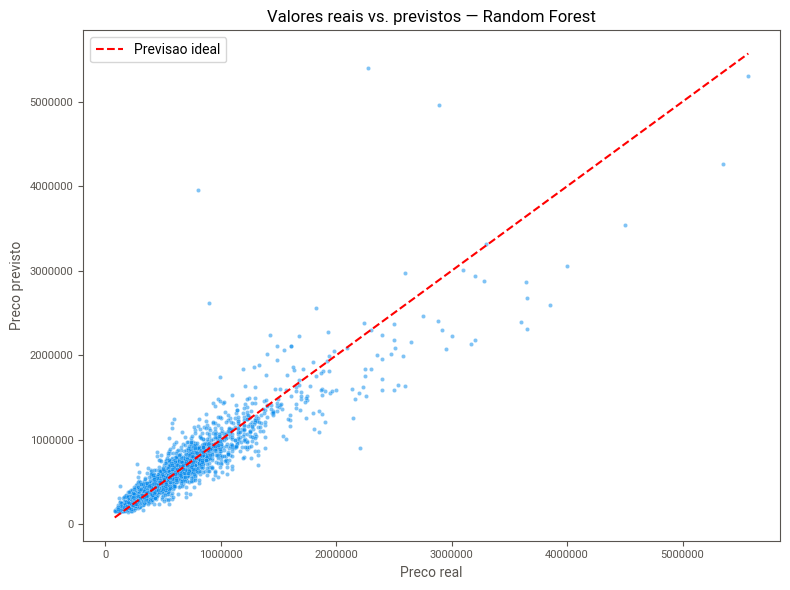

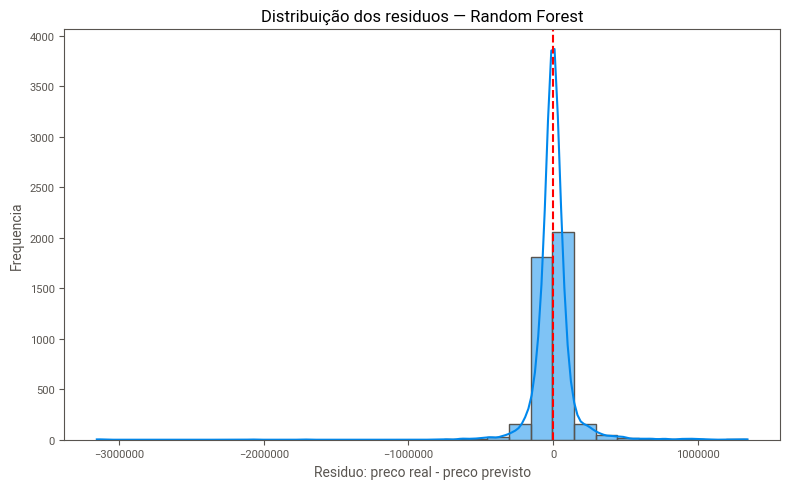

Primeiras 10 previsoes do melhor modelo:


,actual_price,predicted_price,residual,absolute_error
0,"$365,000.00","$358,904.08","$6,095.92","$6,095.92"
1,"$865,000.00","$828,220.71","$36,779.29","$36,779.29"
2,"$1,038,000.00","$1,085,857.80","$-47,857.80","$47,857.80"
3,"$1,490,000.00","$1,948,034.50","$-458,034.50","$458,034.50"
4,"$711,000.00","$712,826.57","$-1,826.57","$1,826.57"
5,"$211,000.00","$245,550.15","$-34,550.15","$34,550.15"
6,"$790,000.00","$869,781.00","$-79,781.00","$79,781.00"
7,"$680,000.00","$609,053.91","$70,946.09","$70,946.09"
8,"$384,500.00","$427,365.23","$-42,865.23","$42,865.23"
9,"$605,000.00","$514,935.53","$90,064.47","$90,064.47"


In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparacao visual entre precos reais e previstos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.5)

min_price = min(y_test.min(), best_predictions.min())
max_price = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color='red',
    linestyle='--',
    label='Previsao ideal'
)

plt.title(f'Valores reais vs. previstos — {best_model_name}')
plt.xlabel('Preco real')
plt.ylabel('Preco previsto')
plt.legend()
plt.tight_layout()
plt.show()

# Residuos: preco real menos preco previsto
residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title(f'Distribuição dos residuos — {best_model_name}')
plt.xlabel('Residuo: preco real - preco previsto')
plt.ylabel('Frequencia')
plt.tight_layout()
plt.show()

# Tabela com exemplos de previsoes
prediction_comparison = pd.DataFrame({
    'actual_price': y_test.values,
    'predicted_price': best_predictions,
    'residual': residuals.values,
    'absolute_error': abs(residuals.values)
})

print('Primeiras 10 previsoes do melhor modelo:')
display(
    prediction_comparison.head(10).style.format({
        'actual_price': '${:,.2f}',
        'predicted_price': '${:,.2f}',
        'residual': '${:,.2f}',
        'absolute_error': '${:,.2f}'
    })
)

Foram treinados três modelos de regressão: Regressão Linear, Random Forest e Gradient Boosting. A avaliação foi realizada no conjunto de teste, que não participou do ajuste dos modelos.

A comparação utilizou as métricas MAE, RMSE e R². O modelo final foi selecionado pelo menor RMSE, pois essa métrica penaliza com maior intensidade erros elevados de previsão.

Os gráficos de preços reais versus previstos e a distribuição dos resíduos permitem avaliar visualmente a qualidade das estimativas e identificar possíveis padrões de erro. Não foi realizada otimização de hiperparâmetros, pois o objetivo deste projeto é desenvolver uma solução acadêmica, funcional e reprodutível para prever preços de imóveis.

# 6. Interpretação do Modelo e Conclusão

Como o Random Forest apresentou o melhor desempenho segundo o menor RMSE no conjunto de teste, ele foi selecionado como modelo final para prever o preço dos imóveis. Nesta etapa, serão analisadas as variáveis mais importantes para as previsões e consolidadas as conclusões do projeto.

## 6.1 Importância das variáveis

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Confirmacao do modelo selecionado
if best_model_name != 'Random Forest':
    print(
        f"Atencao: o modelo selecionado foi '{best_model_name}'. "
        "A analise de importancia sera executada apenas se o modelo possuir feature_importances_."
    )

if not hasattr(best_model, 'feature_importances_'):
    raise AttributeError(
        "O modelo final nao possui o atributo 'feature_importances_'."
    )

# Nomes das variaveis apos o pre-processamento
feature_names = preprocessor.get_feature_names_out()

# Importancias calculadas pelo Random Forest
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print('Top 15 variaveis mais importantes para o Random Forest:')
display(feature_importances.head(15))

Top 15 variaveis mais importantes para o Random Forest:


,feature,importance
0,num__grade,0.32
1,num__sqft_living,0.28
2,num__lat,0.16
3,num__long,0.07
4,num__property_age,0.03
5,num__waterfront,0.03
6,num__sqft_above,0.02
7,num__zipcode,0.02
8,num__sqft_lot,0.01
9,num__view,0.01


/tmp/ipykernel_7647/2552197857.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




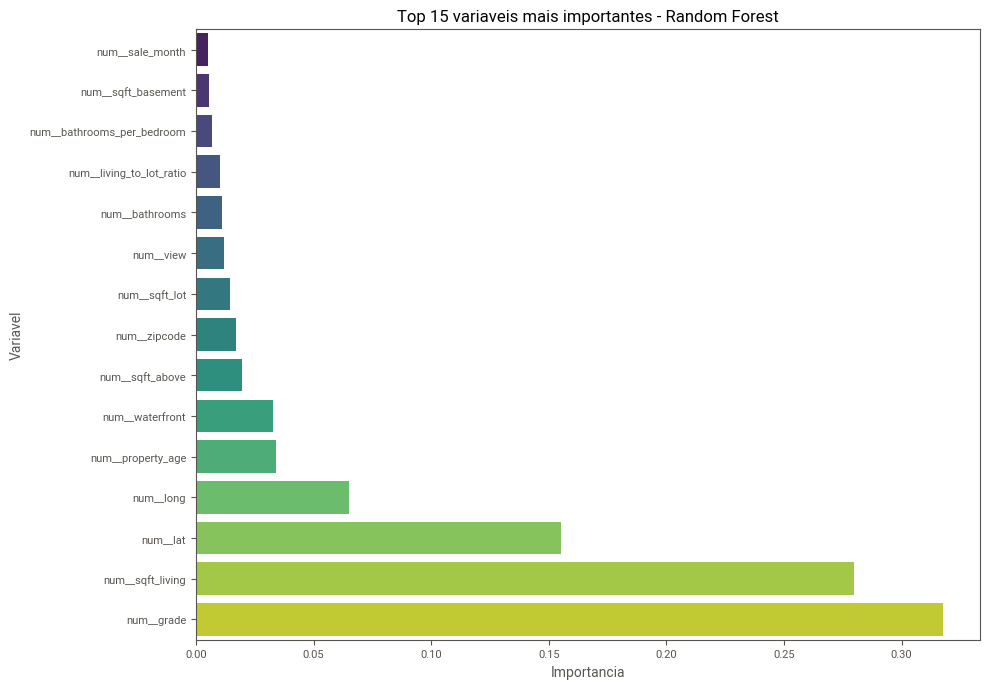

In [129]:
# Grafico das 15 variaveis mais importantes
top_features = feature_importances.head(15).sort_values(
    by='importance',
    ascending=True
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x='importance',
    y='feature',
    palette='viridis'
)

plt.title('Top 15 variaveis mais importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variavel')
plt.tight_layout()
plt.show()

## 6.2 Análise dos erros de previsão

In [130]:
# Classificacao dos erros de previsao do modelo final
prediction_analysis = prediction_comparison.copy()

prediction_analysis['error_percentage'] = (
    prediction_analysis['absolute_error']
    / prediction_analysis['actual_price']
) * 100

print('Resumo dos erros absolutos:')
display(
    prediction_analysis[
        ['actual_price', 'predicted_price', 'absolute_error', 'error_percentage']
    ].describe().T
)

print('10 imoveis com os maiores erros absolutos:')
try:
    display(
        prediction_analysis
        .sort_values(by='absolute_error', ascending=False)
        .head(10)
        .style.format({
            'actual_price': '${:,.2f}',
            'predicted_price': '${:,.2f}',
            'residual': '${:,.2f}',
            'absolute_error': '${:,.2f}',
            'error_percentage': '{:.2f}%'
        })
    )
except Exception:
    display(
        prediction_analysis
        .sort_values(by='absolute_error', ascending=False)
        .head(10)
    )

Resumo dos erros absolutos:


,count,mean,std,min,25%,50%,75%,max
actual_price,4323.00,549367.44,388859.47,82500.00,324950.00,455000.00,655000.00,5570000.00
predicted_price,4323.00,548222.84,364190.09,145294.50,328507.96,461184.00,646694.15,5400002.00
absolute_error,4323.00,72924.96,131341.44,22.54,17033.81,39483.86,80565.32,3153618.00
error_percentage,4323.00,13.16,15.99,0.00,3.97,8.86,16.99,394.20


10 imoveis com os maiores erros absolutos:


,actual_price,predicted_price,residual,absolute_error,error_percentage
2505,"$800,000.00","$3,953,618.00","$-3,153,618.00","$3,153,618.00",394.20%
3275,"$2,280,000.00","$5,400,002.00","$-3,120,002.00","$3,120,002.00",136.84%
4217,"$2,888,000.00","$4,966,866.50","$-2,078,866.50","$2,078,866.50",71.98%
1327,"$900,000.00","$2,614,157.50","$-1,714,157.50","$1,714,157.50",190.46%
1992,"$3,650,000.00","$2,307,342.00","$1,342,658.00","$1,342,658.00",36.79%
1283,"$2,205,000.00","$899,341.37","$1,305,658.63","$1,305,658.63",59.21%
3903,"$3,850,000.00","$2,592,650.00","$1,257,350.00","$1,257,350.00",32.66%
238,"$3,600,000.00","$2,400,614.50","$1,199,385.50","$1,199,385.50",33.32%
1979,"$5,350,000.00","$4,267,380.00","$1,082,620.00","$1,082,620.00",20.24%
447,"$3,168,750.00","$2,140,349.00","$1,028,401.00","$1,028,401.00",32.45%


## 6.3 Conclusão do projeto

In [131]:
# Metricas do modelo final para apoiar a conclusao
final_mae = best_model_metrics['MAE']
final_rmse = best_model_metrics['RMSE']
final_r2 = best_model_metrics['R2']

print(f'Modelo final selecionado: {best_model_name}')
print(f'MAE no conjunto de teste: ${final_mae:,.2f}')
print(f'RMSE no conjunto de teste: ${final_rmse:,.2f}')
print(f'R² no conjunto de teste: {final_r2:.4f}')

print('\nPrincipais variaveis segundo o Random Forest:')
print(feature_importances.head(5)['feature'].tolist())

Modelo final selecionado: Random Forest
MAE no conjunto de teste: $72,924.96
RMSE no conjunto de teste: $150,215.29
R² no conjunto de teste: 0.8507

Principais variaveis segundo o Random Forest:
['num__grade', 'num__sqft_living', 'num__lat', 'num__long', 'num__property_age']


## Conclusão

O objetivo deste projeto foi desenvolver um modelo de Machine Learning capaz de prever o preço de imóveis a partir de atributos estruturais, geográficos, temporais e relacionados à condição de conservação dos imóveis.

Após as etapas de feature engineering, filtragem de variáveis e preparação dos dados, foram comparados os modelos Linear Regression, Random Forest e Gradient Boosting. O Random Forest foi selecionado como modelo final por apresentar o menor RMSE no conjunto de teste.

A avaliação considerou as métricas MAE, RMSE e R². O MAE representa, em média, o erro absoluto das previsões em valor monetário. O RMSE penaliza mais fortemente previsões com erros elevados. Já o R² representa a proporção da variação dos preços explicada pelo modelo.

A análise de importância das variáveis permite identificar os atributos que mais contribuíram para as previsões do Random Forest. Essas informações podem apoiar a avaliação de imóveis, destacando a relevância de aspectos como tamanho, qualidade, localização, número de ambientes, condição e características adicionais.

Como limitações, o modelo pode apresentar maior erro em imóveis muito caros, imóveis com características raras ou propriedades fora do padrão predominante na base. Além disso, este projeto não utilizou otimização de hiperparâmetros, pois teve como objetivo construir uma solução acadêmica, funcional, interpretável e reprodutível.

# 7. Salvamento do Modelo para Deploy

Nesta etapa, o Random Forest selecionado será combinado com o pré-processador utilizado no treinamento. O artefato final será salvo para ser carregado no dashboard Streamlit e utilizado para realizar previsões de novos imóveis.

## 7.1 Criação do pipeline final

In [132]:
from sklearn.pipeline import Pipeline

# Validacao do modelo vencedor
if best_model_name != 'Random Forest':
    raise ValueError(
        f"O modelo vencedor esperado era Random Forest, mas foi encontrado: {best_model_name}."
    )

# Pipeline final para receber dados brutos e gerar previsoes
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

print('Pipeline final criado com sucesso.')
print(final_pipeline)

Pipeline final criado com sucesso.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'waterfront',
                                                   'view', 'condition', 'grade',
                                                   'sqft_above',
                                                   'sqft_basement', 'zipcode',
                                                   'lat', 'long', 'sale_year

## 7.2 Teste de previsão com dados brutos

In [133]:
import numpy as np

# Usa uma pequena amostra de X_test bruto para validar o pipeline completo
new_properties_test = X_test.head(5).copy()

# Previsao usando o pipeline completo: pre-processamento + Random Forest
test_predictions = final_pipeline.predict(new_properties_test)

prediction_test_df = new_properties_test.copy()
prediction_test_df['predicted_price'] = test_predictions

print('Teste de previsao realizado com sucesso:')
display(prediction_test_df.head())

Teste de previsao realizado com sucesso:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,sale_year,sale_month,sale_quarter,property_age,was_renovated,years_since_renovation,has_basement,living_to_lot_ratio,bathrooms_per_bedroom,predicted_price
735,4,2.25,2070,8893,2.00,0,0,4,8,2070,...,2014,10,4,28.00,0,NaN,0,0.23,0.56,358904.08
2830,5,3.00,2900,6730,1.00,0,0,5,8,1830,...,2014,8,3,37.00,0,NaN,1,0.43,0.60,828220.71
4106,4,2.50,3770,10893,2.00,0,2,3,11,3770,...,2014,8,3,17.00,0,NaN,0,0.35,0.62,1085857.80
16218,3,3.50,4560,14608,2.00,0,2,3,12,4560,...,2015,3,1,25.00,0,NaN,0,0.31,1.17,1948034.50
19964,3,2.50,2550,5376,2.00,0,0,3,9,2550,...,2014,7,3,10.00,0,NaN,0,0.47,0.83,712826.57


## 7.3 Salvamento do artefato de Machine Learning

In [134]:
import os
import joblib

# Cria a pasta para armazenar o modelo, caso ainda nao exista
os.makedirs('models', exist_ok=True)

# Caminho do artefato que sera carregado no Streamlit
model_path = 'models/house_price_random_forest_pipeline.joblib'

# Salva o pipeline completo, incluindo preprocessor e Random Forest
joblib.dump(final_pipeline, model_path)

# Valida se o arquivo foi criado corretamente
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    print(f'Modelo salvo com sucesso em: {model_path}')
    print(f'Tamanho do arquivo: {os.path.getsize(model_path) / (1024 * 1024):.2f} MB')
else:
    raise FileNotFoundError(
        'O arquivo do modelo nao foi criado ou esta vazio.'
    )

Modelo salvo com sucesso em: models/house_price_random_forest_pipeline.joblib
Tamanho do arquivo: 145.52 MB


## 7.4 Validação do modelo salvo

In [135]:
# Carrega o arquivo salvo para validar que ele pode ser usado no dashboard
loaded_pipeline = joblib.load(model_path)

# Realiza previsao novamente com os mesmos dados brutos
loaded_predictions = loaded_pipeline.predict(new_properties_test)

# Compara previsoes do pipeline em memoria com as previsoes do arquivo carregado
predictions_match = np.allclose(test_predictions, loaded_predictions)

print(f'O modelo carregado gera as mesmas previsoes: {predictions_match}')

if predictions_match:
    print('Artefato validado e pronto para integracao com Streamlit.')
else:
    raise ValueError(
        'As previsoes do modelo carregado sao diferentes das previsoes originais.'
    )

O modelo carregado gera as mesmas previsoes: True
Artefato validado e pronto para integracao com Streamlit.


O artefato salvo reúne o pré-processador e o modelo Random Forest em um único pipeline. Dessa forma, novos imóveis enviados pelo dashboard Streamlit serão submetidos às mesmas regras de imputação, codificação e escalonamento aplicadas durante o treinamento.

O arquivo `house_price_random_forest_pipeline.joblib` pode ser carregado no Streamlit para realizar previsões a partir de dados brutos, desde que as colunas de entrada sejam compatíveis com as variáveis utilizadas no treinamento.

# 8. Modelo Compacto para Deploy

Criacao de uma versao compacta do Random Forest para viabilizar o deploy no Streamlit hospedado pelo Render, contornando a restricao do GitHub para arquivos acima de 100 MB.

## 8.1 Treinamento do Random Forest compacto

In [160]:
from sklearn.ensemble import RandomForestRegressor

# Modelo Random Forest compacto para reducao de tamanho de arquivo
compact_random_forest = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=3,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

# Treinamento exclusivo nos dados de treino preparados
compact_random_forest.fit(X_train_prepared, y_train)
print('Modelo Random Forest compacto treinado com sucesso.')

Modelo Random Forest compacto treinado com sucesso.


## 8.2 Avaliação do modelo compacto

In [161]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Previsoes do modelo compacto no conjunto de teste
y_pred_compact = compact_random_forest.predict(X_test_prepared)

# Metricas do modelo compacto
mae_compact = mean_absolute_error(y_test, y_pred_compact)
rmse_compact = np.sqrt(mean_squared_error(y_test, y_pred_compact))
r2_compact = r2_score(y_test, y_pred_compact)

# Tabela comparativa entre o modelo campeao original e a versao compacta
comparison_data = [
    {
        'Modelo': f'Original ({best_model_name})',
        'MAE': best_model_metrics['MAE'],
        'RMSE': best_model_metrics['RMSE'],
        'R2': best_model_metrics['R2']
    },
    {
        'Modelo': 'Random Forest Compacto',
        'MAE': mae_compact,
        'RMSE': rmse_compact,
        'R2': r2_compact
    }
]

comparison_df = pd.DataFrame(comparison_data)
print('Comparacao de desempenho entre Modelo Original e Modelo Compacto:')
try:
    display(
        comparison_df.style.format({
            'MAE': '${:,.2f}',
            'RMSE': '${:,.2f}',
            'R2': '{:.4f}'
        })
    )
except Exception:
    display(comparison_df)

# Analise de diferenca percentual de RMSE
rmse_diff_pct = ((rmse_compact - best_model_metrics['RMSE']) / best_model_metrics['RMSE']) * 100
print(f'\nDiferenca percentual no RMSE: {rmse_diff_pct:+.2f}%')

if rmse_diff_pct <= 10.0:
    print('Avaliacao: O modelo compacto mantem desempenho proximo ao modelo original (RMSE dentro do limite aceitavel de 10%).')
else:
    print('Avaliacao: O RMSE do modelo compacto e superior a 10% em relacao ao modelo original.')

Comparacao de desempenho entre Modelo Original e Modelo Compacto:


,Modelo,MAE,RMSE,R2
0,Original (Random Forest),"$72,924.96","$150,215.29",0.8507
1,Random Forest Compacto,"$73,356.89","$149,768.08",0.8516



Diferenca percentual no RMSE: -0.30%
Avaliacao: O modelo compacto mantem desempenho proximo ao modelo original (RMSE dentro do limite aceitavel de 10%).


## 8.3 Salvamento e validação do artefato compacto

In [153]:
import os
import joblib
from sklearn.pipeline import Pipeline

# Pipeline compacto unindo preprocessor existente e o modelo compacto
compact_final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', compact_random_forest)
])

# Caminho exclusivo para o artefato compacto
compact_model_path = 'models/house_price_random_forest_compact_pipeline.joblib'
os.makedirs('models', exist_ok=True)

# Salvamento do pipeline compacto
joblib.dump(compact_final_pipeline, compact_model_path)

# Checagem do tamanho do arquivo
file_size_bytes = os.path.getsize(compact_model_path)
file_size_mb = file_size_bytes / (1024 * 1024)

print(f'Artefato compacto salvo em: {compact_model_path}')
print(f'Tamanho do arquivo: {file_size_mb:.2f} MB')

# Validacao por recarregamento e predicao em dados brutos
test_sample_bruta = X_test.head(5).copy()
test_pred_compact = compact_final_pipeline.predict(test_sample_bruta)

loaded_compact_pipeline = joblib.load(compact_model_path)
loaded_pred_compact = loaded_compact_pipeline.predict(test_sample_bruta)

predictions_match_compact = np.allclose(test_pred_compact, loaded_pred_compact)
print(f'Validacao de paridade das previsoes do modelo compacto: {predictions_match_compact}')

# Verificacao do limite de tamanho para o GitHub (95 MB)
if file_size_mb > 95.0:
    print('Aviso: O arquivo do modelo compacto continua acima de 95 MB. Uma versao ainda menor sera necessaria para deploy no GitHub/Render.')
else:
    print('Sucesso: O arquivo esta abaixo do limite de 95 MB e pronto para envio ao GitHub/Render.')

Artefato compacto salvo em: models/house_price_random_forest_compact_pipeline.joblib
Tamanho do arquivo: 54.09 MB
Validacao de paridade das previsoes do modelo compacto: True
Sucesso: O arquivo esta abaixo do limite de 95 MB e pronto para envio ao GitHub/Render.


### Resumo do Modelo Compacto e Deploy

- **Modelo campeão acadêmico**: O Random Forest original permanece como a solução principal do projeto devido à sua maior capacidade estatística.
- **Objetivo do modelo compacto**: A versão reduzida foi construída exclusivamente para viabilizar o deploy no Streamlit/Render, respeitando os limites de armazenamento do GitHub.
- **Consistência de avaliação**: A comparação foi realizada rigorosamente sobre o mesmo conjunto de teste isolado.
- **Reuso do pré-processador**: O pipeline compacto reaproveita o mesmo objeto `preprocessor` já ajustado nos dados de treino.
- **Critério de uso**: O artefato compacto só deverá ser utilizado no aplicativo Streamlit caso seu tamanho final esteja abaixo dos limites do repositório e apresente desempenho preditivo aceitável.